# Tutorial: Motor Protein Energy Analysis

## Overview
This tutorial demonstrates how to analyze interaction energies of 18 kinesin motor proteins across three nucleotide states (ADP, APO, ATP) to identify functional families and understand evolutionary strategies.

## Learning Objectives
By the end of this tutorial, you will:
- Understand how to preprocess molecular dynamics energy data
- Apply principal component analysis to identify main energy patterns
- Use clustering algorithms to group motors by functional similarity
- Validate clustering results using silhouette analysis
- Interpret biological significance of energy landscapes

## Scientific Background
Motor proteins convert chemical energy (ATP hydrolysis) into mechanical work. The energy landscape across nucleotide states determines functional properties:
- **Processivity**: How long a motor stays attached to microtubules
- **Velocity**: Speed of movement along microtubules  
- **Duty cycle**: Fraction of time spent strongly bound to microtubules


## Step 1: Setup and Data Loading

### What we're doing:
First, we import necessary libraries and load the energy data from molecular dynamics simulations.

### Why this matters:
Proper data loading and preprocessing is crucial for accurate analysis. We need to:
1. Load energy data from three nucleotide states (ADP, APO, ATP)
2. Calculate equilibrium values (mean from 25ns onwards)
3. Standardize the data for fair comparison between motors


In [23]:
# Import libraries and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score
import scipy.stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print("Starting Motor Protein Energy Analysis Tutorial...")


Libraries imported successfully!
Starting Motor Protein Energy Analysis Tutorial...


In [24]:
# Load energy data from molecular dynamics simulations
print("="*60)
print("STEP 1: DATA LOADING AND PREPROCESSING")
print("="*60)

# Load energy data
df_ADP = pd.read_csv("../Jiapei/MD_motors/interaction energy/ADP_energy_final.csv")
df_APO = pd.read_csv("../Jiapei/MD_motors/interaction energy/APO_energy_final.csv")
df_ATP = pd.read_csv("../Jiapei/MD_motors/interaction energy/ATP_energy_final.csv")

# Calculate mean energies from 25ns onwards (equilibrium values)
mean_from_25ns_ADP = df_ADP[df_ADP[df_ADP.columns[0]] >= 25].mean()
mean_from_25ns_APO = df_APO[df_APO[df_APO.columns[0]] >= 25].mean()
mean_from_25ns_ATP = df_ATP[df_ATP[df_ATP.columns[0]] >= 25].mean()

# Combine into single DataFrame
energies = pd.DataFrame({
    'ADP': mean_from_25ns_ADP,
    'APO': mean_from_25ns_APO,
    'ATP': mean_from_25ns_ATP
}).iloc[1:]  # Remove time column

# Exclude 'b', 'c', 'd', 'e', 'f', 'g' from the energies DataFrame
# excluded = ['acsu2', 'adpa', 'dipu', 'heal', 'kif5a', 'nagr', 'thtr', 'acsu', 'tila', 'unc']
# excluded = ['b', 'c', 'd', 'e', 'f', 'g', 'k401', 'kif3']
excluded = ['b', 'c', 'd', 'e', 'f', 'g',]

# excluded = []

energies = energies[~energies.index.isin(excluded)]

# Standardize data for fair comparison
scaler = StandardScaler()
energies_scaled = pd.DataFrame(
    scaler.fit_transform(energies),
    index=energies.index,
    columns=energies.columns
)

print(f"Energy data shape: {energies.shape}")
print(f"Motor proteins: {list(energies.index)}")
print("✓ Data loaded and standardized")


STEP 1: DATA LOADING AND PREPROCESSING
Energy data shape: (12, 3)
Motor proteins: ['k401', 'kif3', 'acsu2', 'adpa', 'dipu', 'heal', 'kif5a', 'nagr', 'thtr', 'acsu', 'tila', 'unc']
✓ Data loaded and standardized


## Step 2: Exploratory Data Analysis

### What we're doing:
Now we explore the energy data to understand its characteristics before applying advanced analysis techniques.

### Why this matters:
Exploratory analysis helps us:
1. **Understand data quality** - Check for outliers and data consistency
2. **Verify energy conservation** - The ATP cycle should be energetically balanced
3. **Identify patterns** - See how different motors behave across nucleotide states
4. **Guide analysis choices** - Determine appropriate methods for clustering


STEP 2: EXPLORATORY DATA ANALYSIS
Basic Statistics:
ADP: -1880.7 ± 152.7 kJ/mol
APO: -1795.5 ± 174.6 kJ/mol
ATP: -1868.0 ± 165.4 kJ/mol

Energy Conservation: 0.00 ± 0.00 kJ/mol


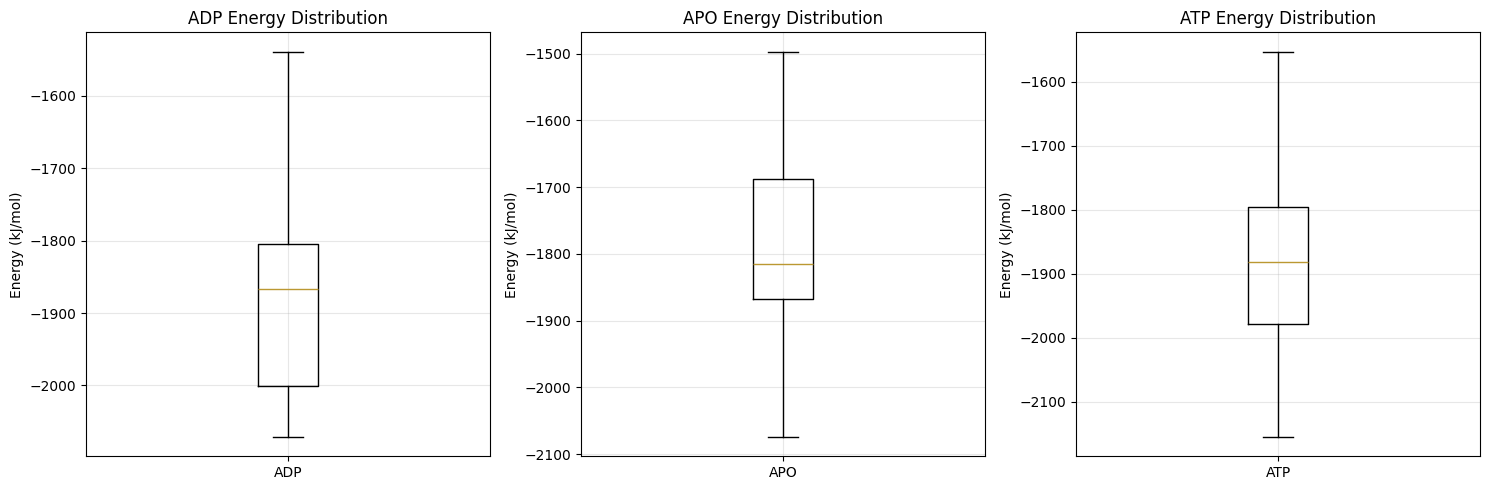

✓ Exploratory analysis complete


In [25]:
# Exploratory Data Analysis
print("="*60)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("="*60)

# Basic statistics
print("Basic Statistics:")
for state in ['ADP', 'APO', 'ATP']:
    print(f"{state}: {energies[state].mean():.1f} ± {energies[state].std():.1f} kJ/mol")

# Calculate energy transitions
transitions = pd.DataFrame({
    'ADP_to_APO': energies['APO'] - energies['ADP'],
    'APO_to_ATP': energies['ATP'] - energies['APO'],
    'ATP_to_ADP': energies['ADP'] - energies['ATP']
})

# Energy conservation check
cycle_energy = transitions['ADP_to_APO'] + transitions['APO_to_ATP'] + transitions['ATP_to_ADP']
print(f"\nEnergy Conservation: {cycle_energy.mean():.2f} ± {cycle_energy.std():.2f} kJ/mol")

# Create exploratory plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Energy distributions
for i, state in enumerate(['ADP', 'APO', 'ATP']):
    axes[i].boxplot(energies[state], labels=[state])
    axes[i].set_title(f'{state} Energy Distribution')
    axes[i].set_ylabel('Energy (kJ/mol)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Exploratory analysis complete")


## Step 3: Principal Component Analysis (PCA)

### What we're doing:
We apply PCA to identify the main sources of variation in the energy data and reduce dimensionality.

### Why PCA matters:
1. **Dimensionality reduction** - Reduces 3D energy space to 2D for visualization
2. **Pattern identification** - Finds the main ways motors differ energetically
3. **Noise reduction** - Focuses on major patterns, not minor variations
4. **Clustering preparation** - Provides clean data for clustering algorithms

### Expected results:
- **PC1** should explain 60-80% of variance (main energy pattern)
- **PC2** should explain 15-25% of variance (secondary pattern)
- **PC3** should explain remaining variance


In [26]:
energies

,ADP,APO,ATP
k401,-1758.962391,-1550.184006,-1552.809780
kif3,-1806.459957,-1838.572009,-1998.817542
acsu2,-1851.708912,-1662.519335,-1835.155743
adpa,-1882.006800,-1802.427027,-1811.677343
dipu,-1987.461179,-1790.369236,-1869.607078
heal,-2062.985107,-1914.538891,-1924.583674
kif5a,-1800.940806,-1696.683850,-1744.955938
nagr,-1939.746648,-2074.135197,-2009.149030
thtr,-1829.492686,-1826.485807,-1972.533039
acsu,-2071.309930,-1851.652374,-2154.898587


STEP 3: PRINCIPAL COMPONENT ANALYSIS
PC1 explains 81.9% of variance
PC2 explains 11.0% of variance
PC3 explains 7.0% of variance


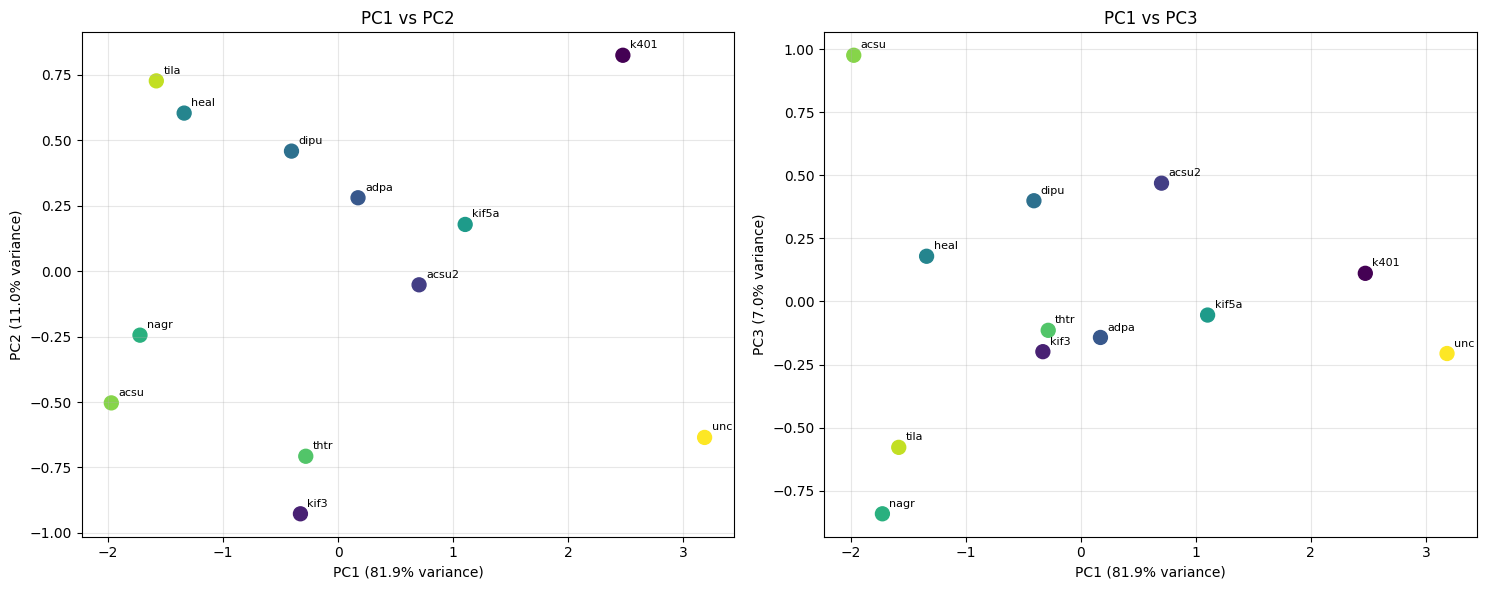

✓ PCA analysis complete


In [27]:
# Principal Component Analysis
print("="*60)
print("STEP 3: PRINCIPAL COMPONENT ANALYSIS")
print("="*60)

# Apply PCA
pca = PCA()
pca_result = pca.fit_transform(energies_scaled)
explained_variance_ratio = pca.explained_variance_ratio_

# Create PCA DataFrame
pca_df = pd.DataFrame(
    pca_result[:, :3],
    columns=['PC1', 'PC2', 'PC3'],
    index=energies.index
)

print(f"PC1 explains {explained_variance_ratio[0]:.1%} of variance")
print(f"PC2 explains {explained_variance_ratio[1]:.1%} of variance")
print(f"PC3 explains {explained_variance_ratio[2]:.1%} of variance")

# Create PCA plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PC1 vs PC2
scatter1 = axes[0].scatter(pca_df['PC1'], pca_df['PC2'], c=range(len(pca_df)), cmap='viridis', s=100)
axes[0].set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)')
axes[0].set_title('PC1 vs PC2')
axes[0].grid(True, alpha=0.3)

# Add motor labels
for i, motor in enumerate(pca_df.index):
    axes[0].annotate(motor, (pca_df['PC1'].iloc[i], pca_df['PC2'].iloc[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

# PC1 vs PC3
scatter2 = axes[1].scatter(pca_df['PC1'], pca_df['PC3'], c=range(len(pca_df)), cmap='viridis', s=100)
axes[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)')
axes[1].set_ylabel(f'PC3 ({explained_variance_ratio[2]:.1%} variance)')
axes[1].set_title('PC1 vs PC3')
axes[1].grid(True, alpha=0.3)

# Add motor labels
for i, motor in enumerate(pca_df.index):
    axes[1].annotate(motor, (pca_df['PC1'].iloc[i], pca_df['PC3'].iloc[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()
print("✓ PCA analysis complete")


## Step 4: Optimal Cluster Number Determination

### What we're doing:
Before clustering, we need to determine the optimal number of clusters using multiple validation metrics.

### Why this matters:
1. **Avoid arbitrary choices** - Don't just pick k=3 because it seems reasonable
2. **Statistical validation** - Use multiple metrics to find the best k
3. **Biological relevance** - The optimal k should make biological sense
4. **Robust results** - Multiple metrics help avoid overfitting

### Methods we use:
- **Silhouette Score**: Measures how well each point fits its cluster (range: -1 to +1, higher is better)
- **Calinski-Harabasz Index**: Ratio of between-cluster to within-cluster variance (higher is better)
- **Davies-Bouldin Index**: Average similarity between clusters (lower is better)

### How we choose the optimal k:
1. **Calculate all three metrics** for k=2 to k=7
2. **Find the best k for each metric** separately
3. **Use consensus approach**: If multiple metrics agree, use that k
4. **Tie-breaker**: If metrics disagree, prefer Silhouette Score (most interpretable)


STEP 4: OPTIMAL CLUSTER NUMBER DETERMINATION
k=2: Silhouette=0.409, Calinski=13.9, Davies-Bouldin=0.786
k=3: Silhouette=0.367, Calinski=14.2, Davies-Bouldin=0.807
k=4: Silhouette=0.370, Calinski=12.2, Davies-Bouldin=0.665
k=5: Silhouette=0.382, Calinski=12.9, Davies-Bouldin=0.551
k=6: Silhouette=0.317, Calinski=13.5, Davies-Bouldin=0.444
k=7: Silhouette=0.319, Calinski=15.9, Davies-Bouldin=0.459

Optimal k based on different metrics:
  Silhouette Score: k=2 (score=0.409)
  Calinski-Harabasz: k=7 (score=15.9)
  Davies-Bouldin: k=6 (score=0.444)
  → Tie detected, using Silhouette Score: k=2


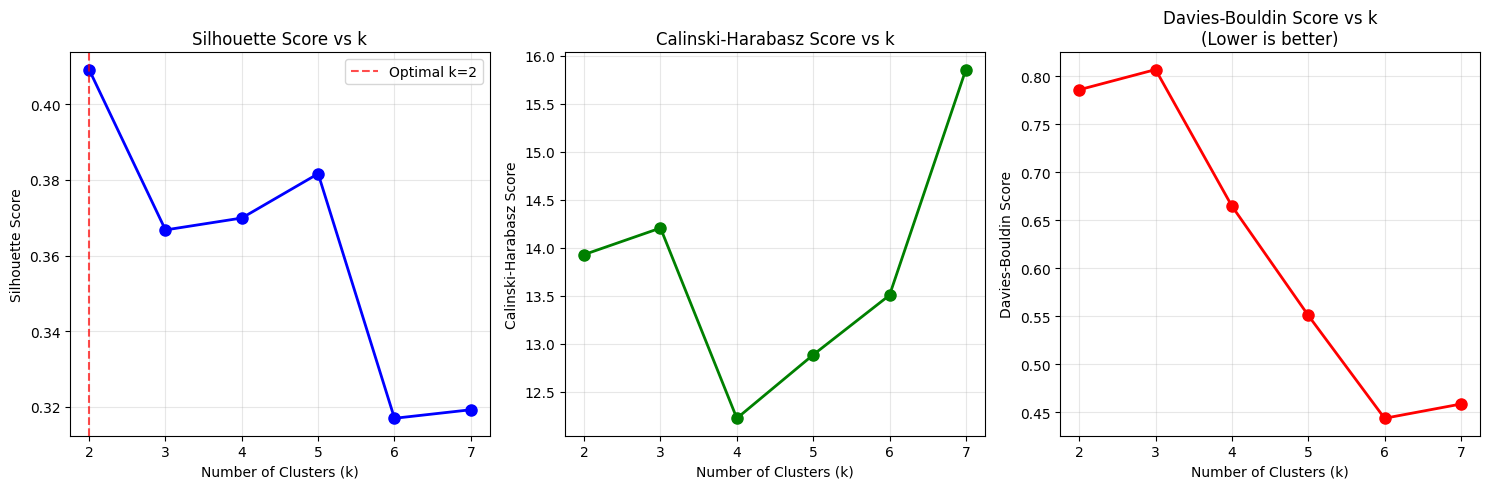

✓ Optimal cluster number determination complete


In [28]:
# Determine optimal number of clusters
print("="*60)
print("STEP 4: OPTIMAL CLUSTER NUMBER DETERMINATION")
print("="*60)

# Test different numbers of clusters
k_range = range(2, 8)
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(energies_scaled)
    
    # Calculate metrics
    sil_score = silhouette_score(energies_scaled, cluster_labels)
    calinski_score = calinski_harabasz_score(energies_scaled, cluster_labels)
    db_score = davies_bouldin_score(energies_scaled, cluster_labels)
    
    silhouette_scores.append(sil_score)
    calinski_scores.append(calinski_score)
    davies_bouldin_scores.append(db_score)
    
    print(f"k={k}: Silhouette={sil_score:.3f}, Calinski={calinski_score:.1f}, Davies-Bouldin={db_score:.3f}")

# Find optimal k using all three metrics
# Silhouette: higher is better
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
# Calinski-Harabasz: higher is better  
optimal_k_calinski = k_range[np.argmax(calinski_scores)]
# Davies-Bouldin: lower is better
optimal_k_davies = k_range[np.argmin(davies_bouldin_scores)]

print(f"\nOptimal k based on different metrics:")
print(f"  Silhouette Score: k={optimal_k_silhouette} (score={max(silhouette_scores):.3f})")
print(f"  Calinski-Harabasz: k={optimal_k_calinski} (score={max(calinski_scores):.1f})")
print(f"  Davies-Bouldin: k={optimal_k_davies} (score={min(davies_bouldin_scores):.3f})")

# Choose the most common k or use silhouette as tie-breaker
k_candidates = [optimal_k_silhouette, optimal_k_calinski, optimal_k_davies]
from collections import Counter
k_counts = Counter(k_candidates)
most_common_k = k_counts.most_common(1)[0][0]

# If there's a tie, prefer silhouette score
if len([k for k, count in k_counts.items() if count == k_counts.most_common(1)[0][1]]) > 1:
    optimal_k = optimal_k_silhouette
    print(f"  → Tie detected, using Silhouette Score: k={optimal_k}")
else:
    optimal_k = most_common_k
    print(f"  → Consensus: k={optimal_k}")

# Visualize the metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Silhouette scores
axes[0].plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k}')
axes[0].legend()

# Calinski-Harabasz scores
axes[1].plot(k_range, calinski_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Calinski-Harabasz Score')
axes[1].set_title('Calinski-Harabasz Score vs k')
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin scores (lower is better)
axes[2].plot(k_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score vs k\n(Lower is better)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Optimal cluster number determination complete")


## Step 5: K-means Clustering and Validation

### What we're doing:
Now we perform the actual clustering using the optimal number of clusters and validate the results.

### Why K-means clustering:
1. **Simple and effective** - Works well for spherical clusters
2. **Fast computation** - Efficient for our dataset size
3. **Interpretable results** - Easy to understand cluster assignments
4. **Widely used** - Standard method in bioinformatics

### Validation methods:
- **Silhouette analysis** - Individual motor fit quality
- **Dendrogram** - Hierarchical relationships for comparison
- **Statistical tests** - ANOVA to test cluster differences


STEP 5: K-MEANS CLUSTERING AND VALIDATION
Cluster Assignments:
Cluster 0: ['kif3', 'adpa', 'dipu', 'heal', 'nagr', 'thtr', 'acsu', 'tila']
Cluster 1: ['k401', 'acsu2', 'kif5a', 'unc']


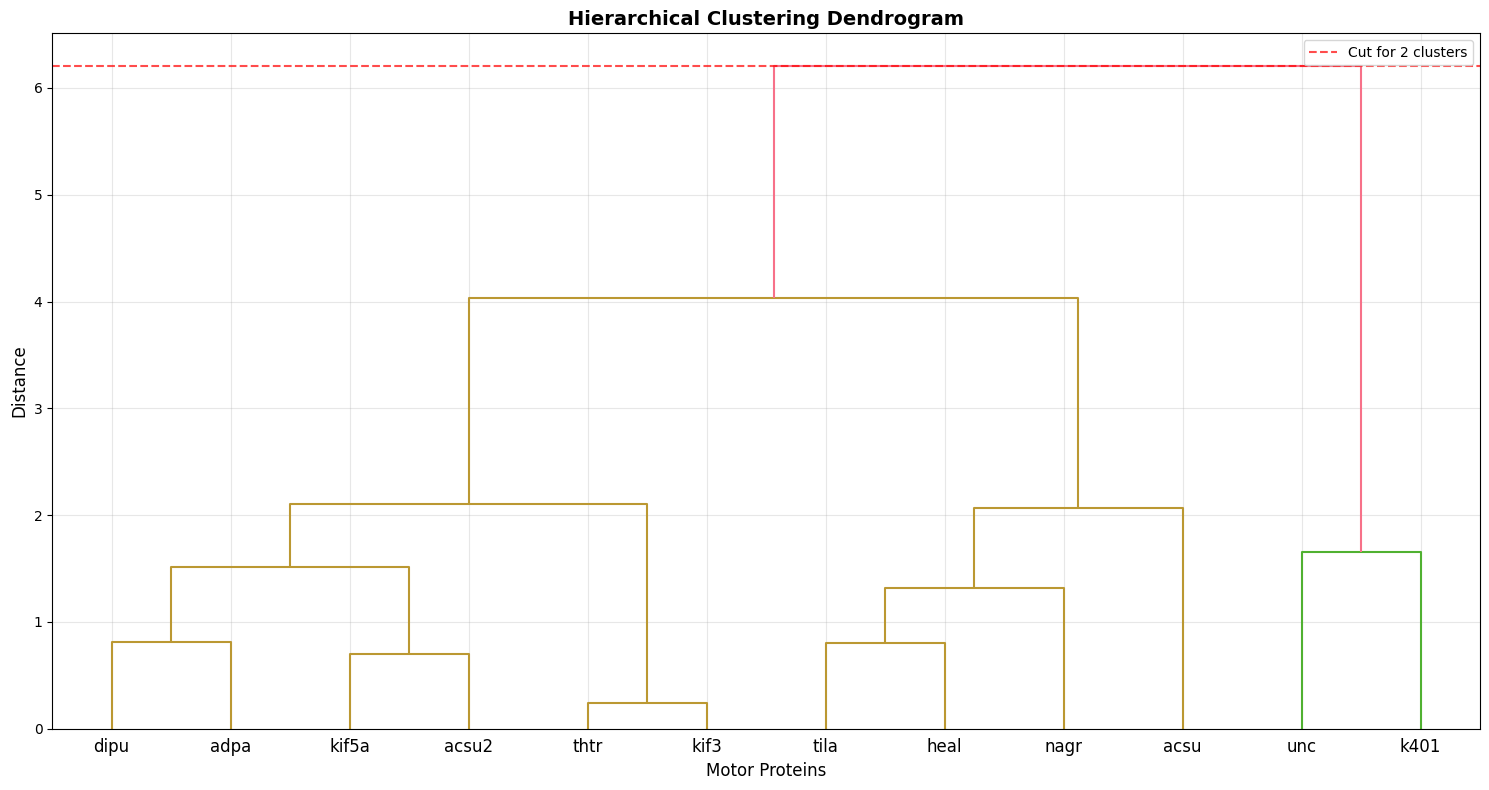

✓ K-means clustering complete


In [29]:
# Perform K-means clustering with optimal k
print("="*60)
print("STEP 5: K-MEANS CLUSTERING AND VALIDATION")
print("="*60)

# Perform final clustering
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(energies)

# Create cluster assignments DataFrame
cluster_assignments = pd.DataFrame({
    'Motor': energies.index,
    'Cluster': cluster_labels,
    'ADP': energies['ADP'],
    'APO': energies['APO'],
    'ATP': energies['ATP']
})

# Add transitions
cluster_assignments['ADP_to_APO'] = cluster_assignments['APO'] - cluster_assignments['ADP']
cluster_assignments['APO_to_ATP'] = cluster_assignments['ATP'] - cluster_assignments['APO']
cluster_assignments['ATP_to_ADP'] = cluster_assignments['ADP'] - cluster_assignments['ATP']

print(f"Cluster Assignments:")
for cluster_id in range(optimal_k):
    cluster_motors = cluster_assignments[cluster_assignments['Cluster'] == cluster_id]['Motor'].tolist()
    print(f"Cluster {cluster_id}: {cluster_motors}")

# Create dendrogram for comparison
distance_matrix = pdist(energies_scaled, metric='euclidean')
linkage_matrix = linkage(distance_matrix, method='ward')

fig, ax = plt.subplots(figsize=(15, 8))
dendrogram(linkage_matrix, 
           labels=energies.index,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           ax=ax)

ax.set_title('Hierarchical Clustering Dendrogram', fontsize=14, fontweight='bold')
ax.set_xlabel('Motor Proteins', fontsize=12)
ax.set_ylabel('Distance', fontsize=12)
ax.grid(True, alpha=0.3)

# Add horizontal line for optimal k
if optimal_k > 1:
    cut_height = linkage_matrix[-(optimal_k-1), 2]
    ax.axhline(y=cut_height, color='red', linestyle='--', alpha=0.7, 
               label=f'Cut for {optimal_k} clusters')
    ax.legend()

plt.tight_layout()
plt.show()
print("✓ K-means clustering complete")


## Step 6: Silhouette Analysis and Cluster Validation

### What we're doing:
We validate the clustering quality using silhouette analysis to ensure our clusters are meaningful.

### Understanding Silhouette Analysis:
- **Silhouette Score**: Measures how well each motor fits its assigned cluster
- **Range**: -1 (poor fit) to +1 (perfect fit)
- **Interpretation**: 
  - **Positive values**: Motor belongs well in its cluster
  - **Negative values**: Motor might belong in a different cluster
  - **Near zero**: Motor is on the border between clusters

### What to look for:
- **High average silhouette score** (>0.3): Good clustering
- **Consistent scores within clusters**: Motors in same cluster have similar fit quality
- **Few negative scores**: Most motors fit well in their assigned clusters


STEP 6: SILHOUETTE ANALYSIS AND CLUSTER VALIDATION


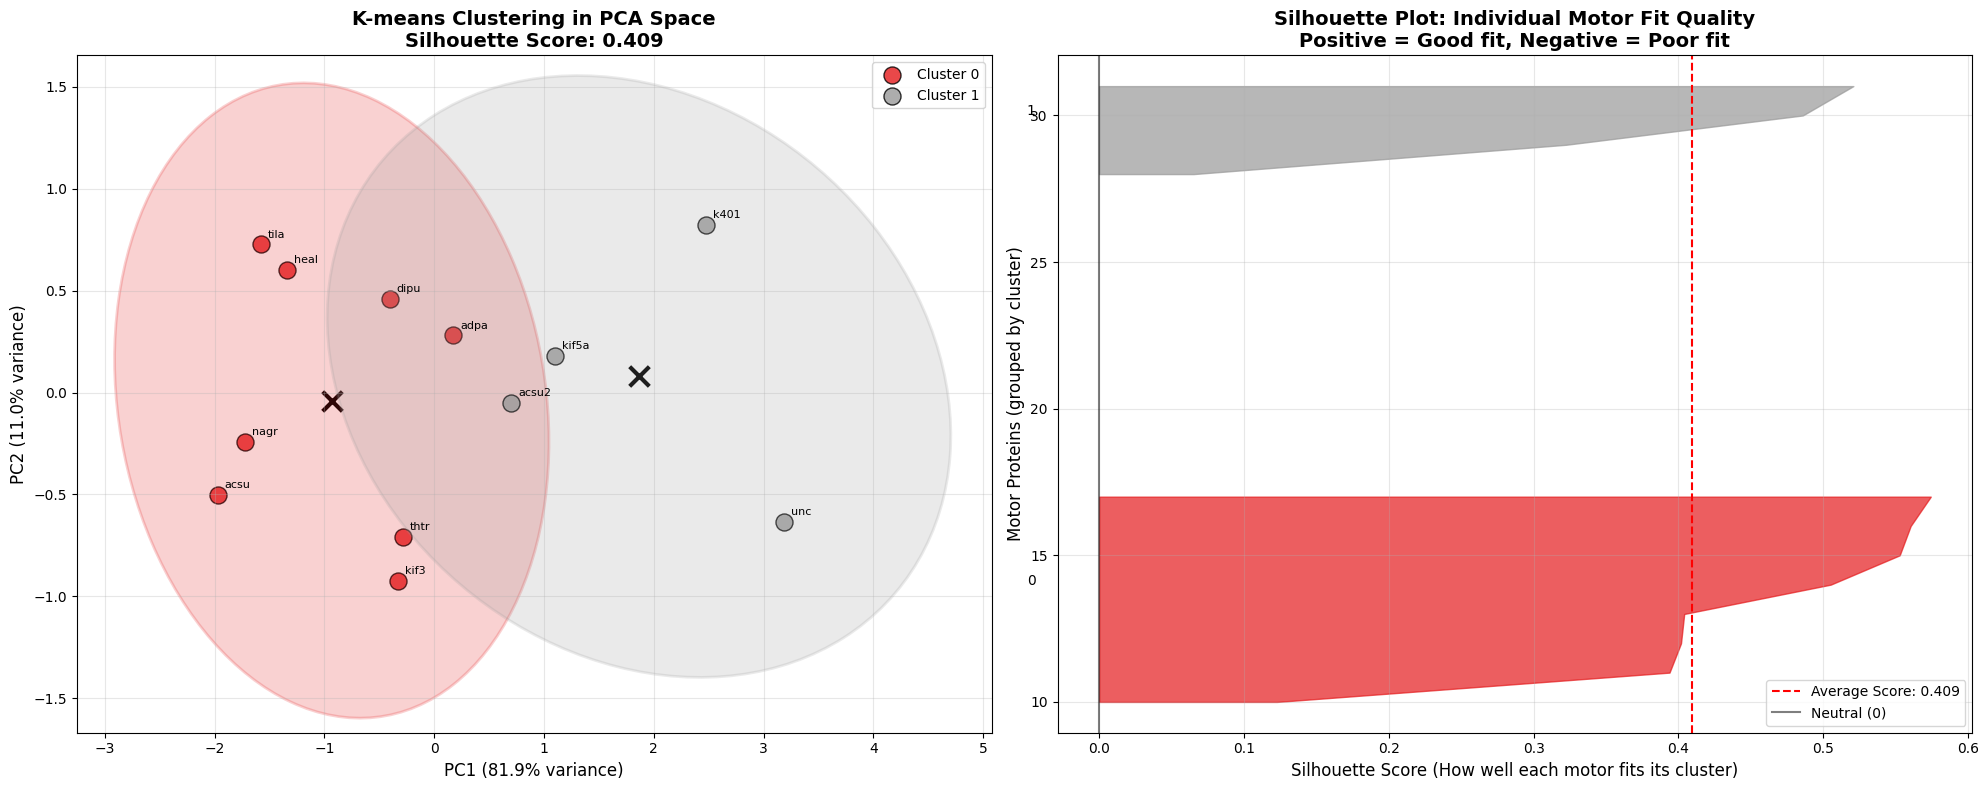

Average Silhouette Score: 0.409
WCSS (Within-Cluster Sum of Squares): 365351.42

Motors with Poor Fit (Silhouette < 0.1):
  acsu2: 0.065
✓ Silhouette analysis complete


In [30]:
# Silhouette Analysis and Cluster Validation
print("="*60)
print("STEP 6: SILHOUETTE ANALYSIS AND CLUSTER VALIDATION")
print("="*60)

# Calculate silhouette scores for each point
silhouette_samples_scores = silhouette_samples(energies_scaled, cluster_labels)
silhouette_avg = silhouette_score(energies_scaled, cluster_labels)

# Create K-means clustering plot with cluster boundaries
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: K-means clustering in PCA space with cluster boundaries (ovals)
colors = plt.cm.Set1(np.linspace(0, 1, optimal_k))

for cluster_id in range(optimal_k):
    cluster_mask = cluster_assignments['Cluster'] == cluster_id
    cluster_points = pca_df[cluster_mask]
    
    # Plot data points for this cluster
    axes[0].scatter(cluster_points['PC1'], cluster_points['PC2'], 
                    c=[colors[cluster_id]], s=150, alpha=0.8, 
                    edgecolors='black', linewidth=1, label=f'Cluster {cluster_id}')
    
    # Add cluster centroid
    centroid_pc1 = cluster_points['PC1'].mean()
    centroid_pc2 = cluster_points['PC2'].mean()
    axes[0].scatter(centroid_pc1, centroid_pc2, marker='x', s=200, 
                   color='black', linewidth=3)
    
    # Draw cluster boundary (oval) using confidence ellipse
    if len(cluster_points) > 2:  # Need at least 3 points for ellipse
        from matplotlib.patches import Ellipse
        from scipy import stats
        
        # Calculate ellipse parameters
        mean_x, mean_y = centroid_pc1, centroid_pc2
        cov_matrix = np.cov(cluster_points['PC1'], cluster_points['PC2'])
        
        # Create confidence ellipse (95% confidence)
        lambda_, v = np.linalg.eigh(cov_matrix)
        lambda_ = np.sqrt(lambda_)
        
        # Scale for 95% confidence
        scale = 2.447  # For 95% confidence (2 degrees of freedom)
        width = lambda_[0] * scale * 2
        height = lambda_[1] * scale * 2
        
        # Calculate angle
        angle = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
        
        # Draw ellipse
        ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle,
                         facecolor=colors[cluster_id], alpha=0.2, 
                         edgecolor=colors[cluster_id], linewidth=2)
        axes[0].add_patch(ellipse)

# Add motor labels
for i, motor in enumerate(pca_df.index):
    axes[0].annotate(motor, (pca_df['PC1'].iloc[i], pca_df['PC2'].iloc[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

axes[0].set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=12)
axes[0].set_title(f'K-means Clustering in PCA Space\nSilhouette Score: {silhouette_avg:.3f}', 
                 fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Silhouette plot showing individual scores
y_lower = 10
for cluster_id in range(optimal_k):
    # Get silhouette scores for this cluster
    cluster_silhouette_values = silhouette_samples_scores[cluster_labels == cluster_id]
    cluster_silhouette_values.sort()
    
    size_cluster = len(cluster_silhouette_values)
    y_upper = y_lower + size_cluster
    
    color = colors[cluster_id]
    axes[1].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
    
    # Label the silhouette plots with their cluster numbers at the middle
    axes[1].text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id))
    
    y_lower = y_upper + 10

axes[1].set_xlabel('Silhouette Score (How well each motor fits its cluster)', fontsize=12)
axes[1].set_ylabel('Motor Proteins (grouped by cluster)', fontsize=12)
axes[1].set_title('Silhouette Plot: Individual Motor Fit Quality\n' + 
                 'Positive = Good fit, Negative = Poor fit', fontsize=14, fontweight='bold')
axes[1].axvline(x=silhouette_avg, color="red", linestyle="--", 
                label=f'Average Score: {silhouette_avg:.3f}')
axes[1].axvline(x=0, color="black", linestyle="-", alpha=0.5, label='Neutral (0)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print silhouette analysis
print(f"Average Silhouette Score: {silhouette_avg:.3f}")
print(f"WCSS (Within-Cluster Sum of Squares): {kmeans_final.inertia_:.2f}")

# Identify motors with poor fit
poor_fit_threshold = 0.1
poor_fit_motors = []

for i, motor in enumerate(energies.index):
    score = silhouette_samples_scores[i]
    if score < poor_fit_threshold:
        poor_fit_motors.append((motor, score))

print(f"\nMotors with Poor Fit (Silhouette < {poor_fit_threshold}):")
if poor_fit_motors:
    for motor, score in poor_fit_motors:
        print(f"  {motor}: {score:.3f}")
else:
    print("  No motors with poor fit identified")

print("✓ Silhouette analysis complete")


STEP 6: SILHOUETTE ANALYSIS AND CLUSTER VALIDATION


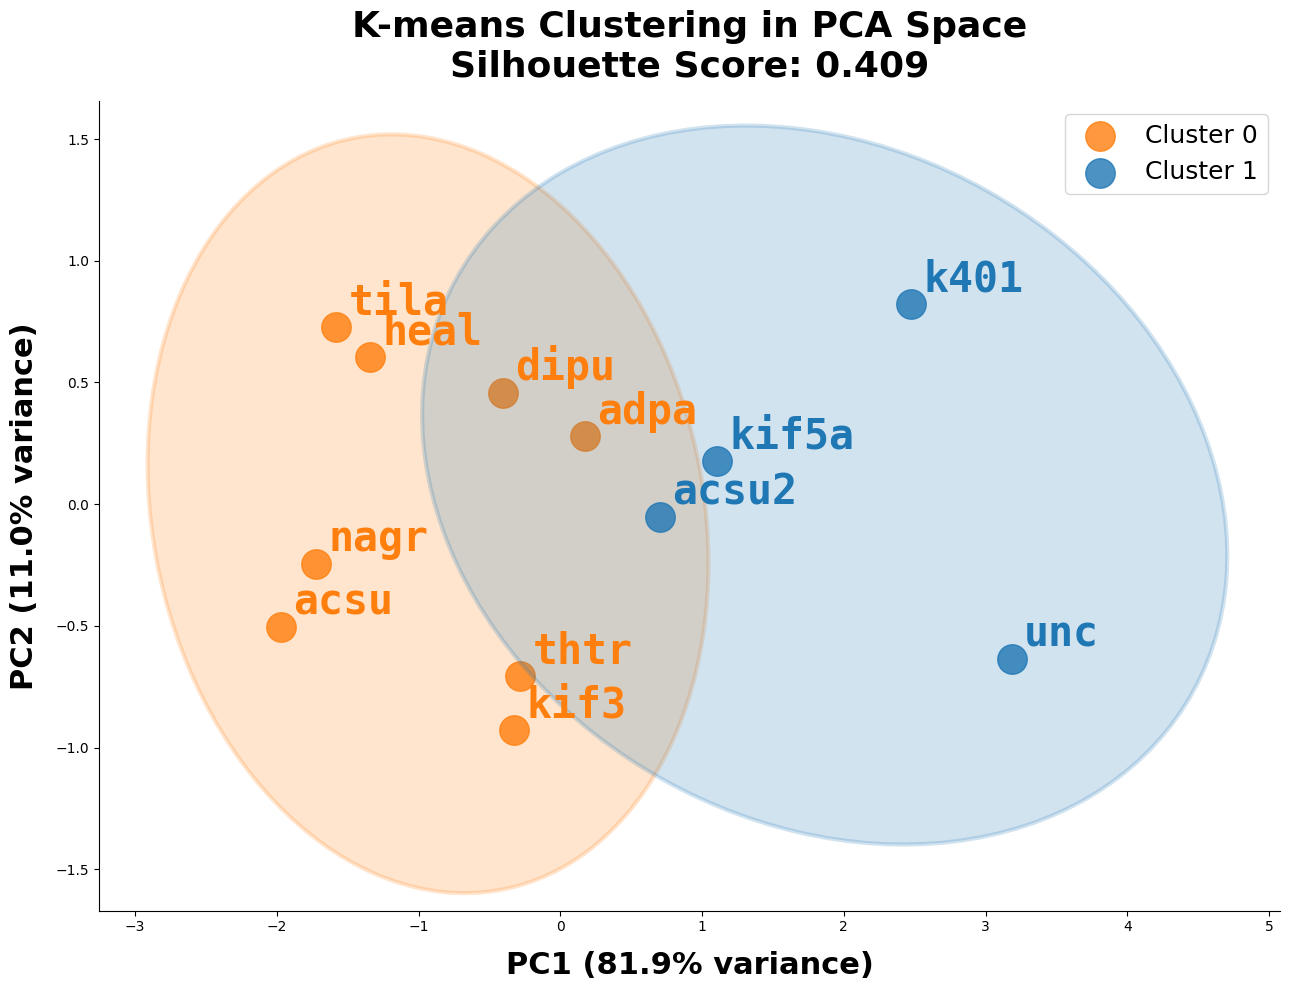

In [31]:
# Silhouette Analysis and Cluster Validation
print("="*60)
print("STEP 6: SILHOUETTE ANALYSIS AND CLUSTER VALIDATION")
print("="*60)

# Calculate silhouette scores for each point
silhouette_samples_scores = silhouette_samples(energies_scaled, cluster_labels)
silhouette_avg = silhouette_score(energies_scaled, cluster_labels)

# Create K-means clustering plot with cluster boundaries
fig, ax = plt.subplots(1, 1, figsize=(13, 10))  # Bigger figure

# Explicit colors: cluster 0 = orange, cluster 1 = blue (swapped order)
cluster_color_map = {0: "#ff7f0e", 1: "#1f77b4"}  # Now cluster 0 is orange, cluster 1 is blue

for cluster_id in range(optimal_k):
    cluster_mask = cluster_assignments['Cluster'] == cluster_id
    cluster_points = pca_df[cluster_mask]
    
    # Set color: cluster 0 orange, cluster 1 blue (swapped)
    cur_color = cluster_color_map.get(cluster_id, "#808080")
    
    # Plot data points for this cluster (make scatters bigger)
    # ELIMINATED CONTOUR: removed edgecolors and linewidth so there is no outline
    ax.scatter(cluster_points['PC1'], cluster_points['PC2'],
               c=cur_color, s=450, alpha=0.8,
               label=f'Cluster {cluster_id}')
    
    # Add cluster centroid coordinates (but do NOT plot X markers)
    centroid_pc1 = cluster_points['PC1'].mean()
    centroid_pc2 = cluster_points['PC2'].mean()
    # (Removed code for plotting 'x' at cluster center)
    
    # Draw cluster boundary (oval) using confidence ellipse
    if len(cluster_points) > 2:  # Need at least 3 points for ellipse
        from matplotlib.patches import Ellipse
        from scipy import stats

        # Calculate ellipse parameters
        mean_x, mean_y = centroid_pc1, centroid_pc2
        cov_matrix = np.cov(cluster_points['PC1'], cluster_points['PC2'])

        # Create confidence ellipse (95% confidence)
        lambda_, v = np.linalg.eigh(cov_matrix)
        lambda_ = np.sqrt(lambda_)

        # Scale for 95% confidence
        scale = 2.447  # For 95% confidence (2 degrees of freedom)
        width = lambda_[0] * scale * 2
        height = lambda_[1] * scale * 2

        # Calculate angle
        angle = np.degrees(np.arctan2(v[1, 0], v[0, 0]))

        # Draw ellipse in proper color
        ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle,
                          facecolor=cur_color, alpha=0.2,
                          edgecolor=cur_color, linewidth=3)
        ax.add_patch(ellipse)

# Add motor labels with the same color as their clusters, make font even bigger
for i, motor in enumerate(pca_df.index):
    # Find the cluster assignment for this motor
    cluster_id = int(cluster_assignments.loc[cluster_assignments.index == motor, 'Cluster'].values[0])
    label_color = cluster_color_map.get(cluster_id, "#808080")
    ax.annotate(motor, (pca_df['PC1'].iloc[i], pca_df['PC2'].iloc[i]),
                xytext=(9, 9), textcoords='offset points', fontsize=30, weight='bold', 
                fontfamily='monospace', color=label_color)

ax.set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=22, weight='bold', labelpad=12)
ax.set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=22, weight='bold', labelpad=12)
ax.set_title(f'K-means Clustering in PCA Space\nSilhouette Score: {silhouette_avg:.3f}',
             fontsize=26, fontweight='bold', pad=18)
# Remove top and right box frame ("spines")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Removed grid
ax.legend(fontsize=18, frameon=True)

plt.tight_layout()

# Save as SVG
fig.savefig("../../../../Downloads/pcaenergyy.svg", format="svg")

plt.show()


## Step 7: Statistical Analysis and Comprehensive Visualizations

### What we're doing:
We perform statistical tests to validate that our clusters represent real functional differences and create comprehensive visualizations.

### Statistical tests we use:
1. **ANOVA tests** - Test if clusters have significantly different energy values
2. **Effect sizes** - Measure the magnitude of differences between clusters
3. **Energy transition analysis** - Understand how motors handle the ATP cycle

### Visualizations we create:
1. **Energy distribution plots** - Show how clusters differ in each nucleotide state
2. **Comprehensive 6-panel analysis** - Multiple views of the data
3. **Statistical summaries** - Quantify the significance of our findings


STEP 7: STATISTICAL ANALYSIS AND COMPREHENSIVE VISUALIZATIONS
Statistical Tests Between Clusters:
ADP energies - F=9.199, p=0.013 *
APO energies - F=20.596, p=0.001 **
ATP energies - F=14.626, p=0.003 **
ADP_to_APO - F=1.248, p=0.290 ns
APO_to_ATP - F=0.169, p=0.690 ns
ATP_to_ADP - F=0.291, p=0.601 ns

Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns=not significant


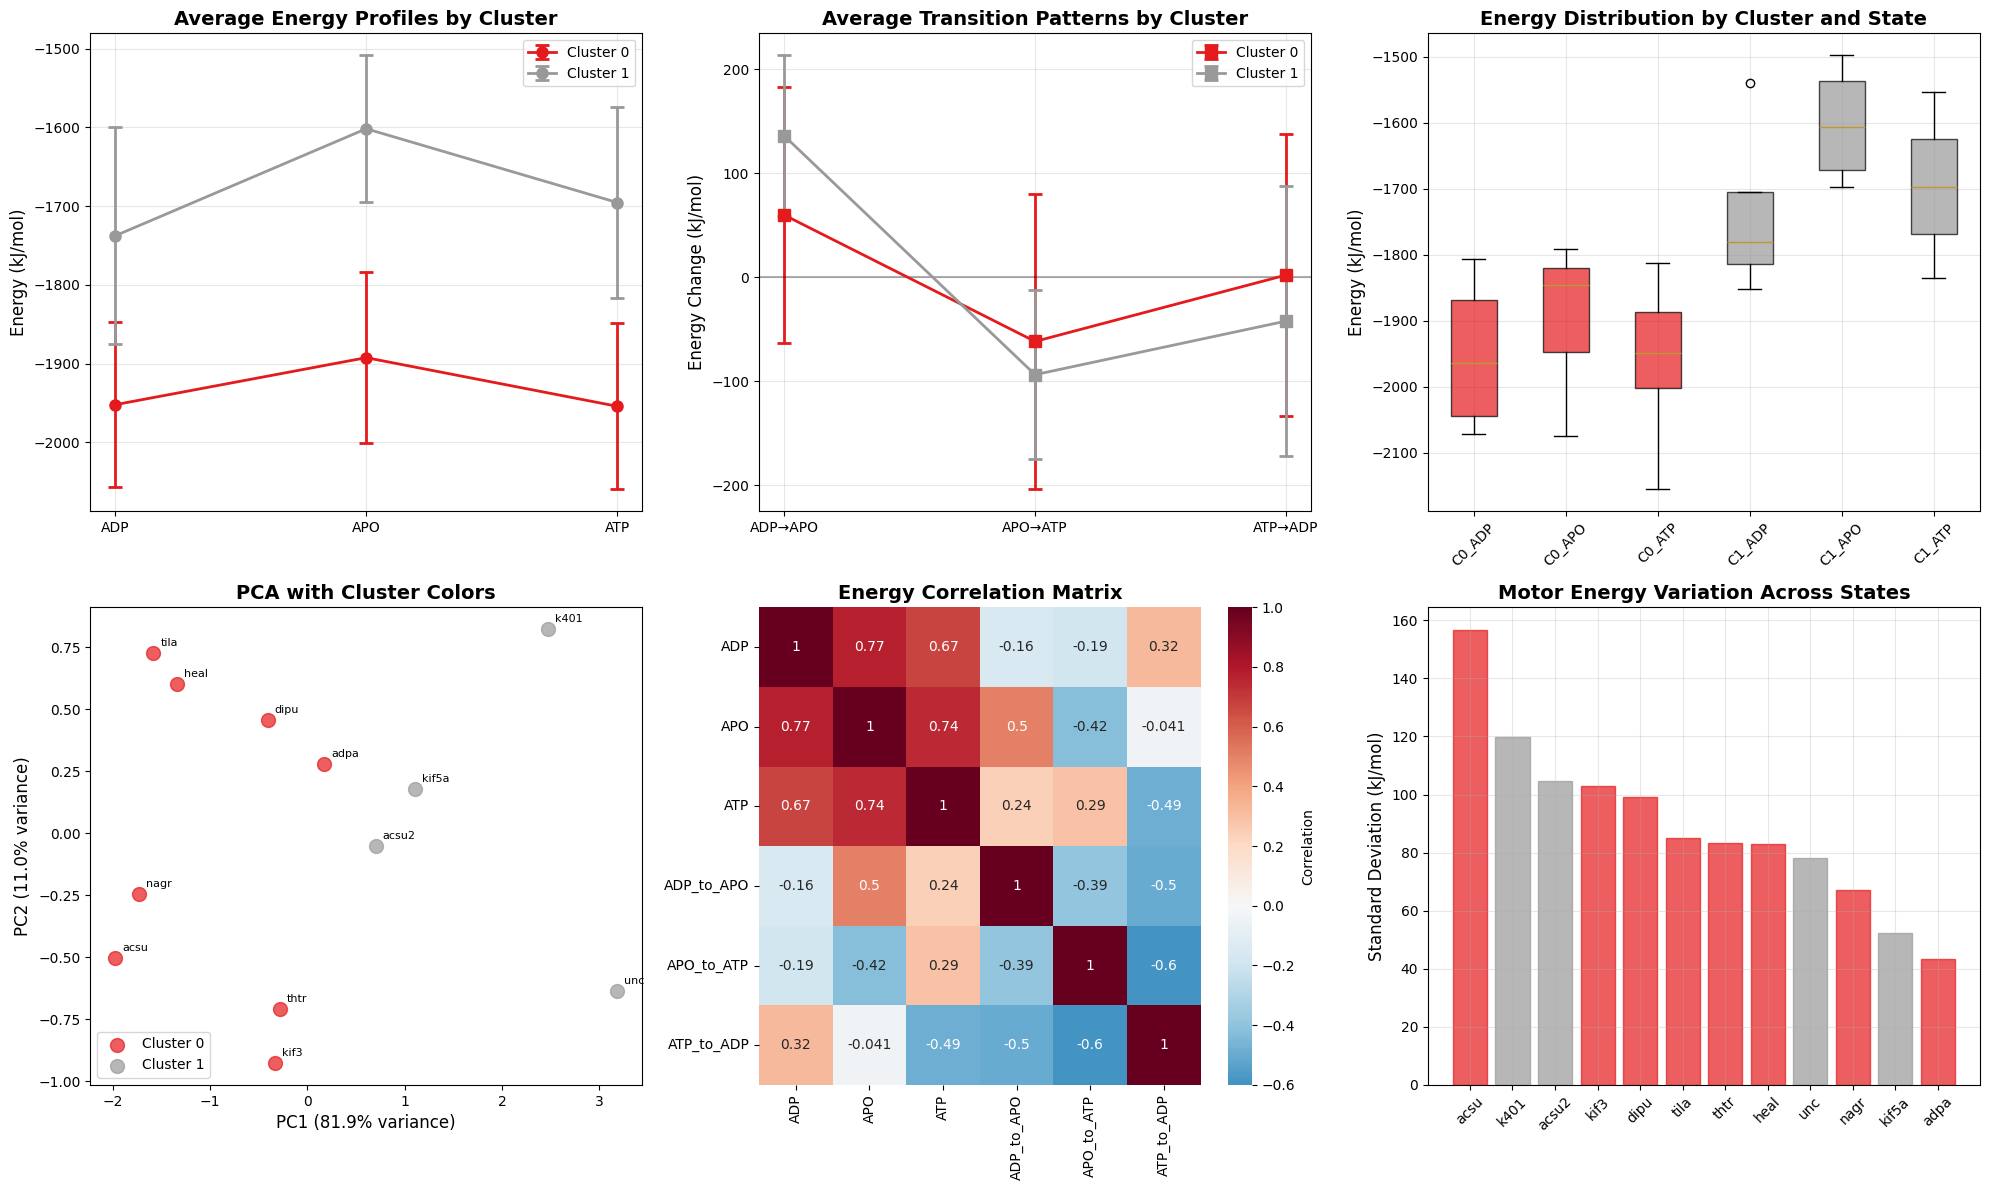

✓ Comprehensive analysis complete


In [32]:
# Statistical Analysis and Comprehensive Visualizations
print("="*60)
print("STEP 7: STATISTICAL ANALYSIS AND COMPREHENSIVE VISUALIZATIONS")
print("="*60)

# Statistical tests between clusters
print("Statistical Tests Between Clusters:")
print("="*40)

# ANOVA tests for each energy state
for state in ['ADP', 'APO', 'ATP']:
    cluster_data = [cluster_assignments[cluster_assignments['Cluster'] == i][state].values 
                   for i in range(optimal_k)]
    f_stat, p_value = scipy.stats.f_oneway(*cluster_data)
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"{state} energies - F={f_stat:.3f}, p={p_value:.3f} {significance}")

# ANOVA tests for transitions
for transition in ['ADP_to_APO', 'APO_to_ATP', 'ATP_to_ADP']:
    cluster_data = [cluster_assignments[cluster_assignments['Cluster'] == i][transition].values 
                   for i in range(optimal_k)]
    f_stat, p_value = scipy.stats.f_oneway(*cluster_data)
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"{transition} - F={f_stat:.3f}, p={p_value:.3f} {significance}")

print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05, ns=not significant")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Plot 1: Energy profiles by cluster
colors = plt.cm.Set1(np.linspace(0, 1, optimal_k))
for cluster_id in range(optimal_k):
    cluster_motors = cluster_assignments[cluster_assignments['Cluster'] == cluster_id]
    states = ['ADP', 'APO', 'ATP']
    means = [cluster_motors[state].mean() for state in states]
    stds = [cluster_motors[state].std() for state in states]
    
    axes[0,0].errorbar(states, means, yerr=stds, marker='o', linewidth=2, 
                      label=f'Cluster {cluster_id}', capsize=5, capthick=2, markersize=8,
                      color=colors[cluster_id])

axes[0,0].set_title('Average Energy Profiles by Cluster', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Energy (kJ/mol)', fontsize=12)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Transition patterns by cluster
for cluster_id in range(optimal_k):
    cluster_motors = cluster_assignments[cluster_assignments['Cluster'] == cluster_id]
    transitions = ['ADP→APO', 'APO→ATP', 'ATP→ADP']
    means = [cluster_motors['ADP_to_APO'].mean(), 
             cluster_motors['APO_to_ATP'].mean(), 
             cluster_motors['ATP_to_ADP'].mean()]
    stds = [cluster_motors['ADP_to_APO'].std(), 
            cluster_motors['APO_to_ATP'].std(), 
            cluster_motors['ATP_to_ADP'].std()]
    
    axes[0,1].errorbar(transitions, means, yerr=stds, marker='s', linewidth=2, 
                      label=f'Cluster {cluster_id}', capsize=5, capthick=2, markersize=8,
                      color=colors[cluster_id])

axes[0,1].set_title('Average Transition Patterns by Cluster', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Energy Change (kJ/mol)', fontsize=12)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Plot 3: Box plots of energies by cluster and state
cluster_energies = []
cluster_names = []
for cluster_id in range(optimal_k):
    cluster_motors = cluster_assignments[cluster_assignments['Cluster'] == cluster_id]
    for state in ['ADP', 'APO', 'ATP']:
        cluster_energies.append(cluster_motors[state].values)
        cluster_names.append(f'C{cluster_id}_{state}')

bp = axes[0,2].boxplot(cluster_energies, labels=cluster_names, patch_artist=True)
axes[0,2].set_title('Energy Distribution by Cluster and State', fontsize=14, fontweight='bold')
axes[0,2].set_ylabel('Energy (kJ/mol)', fontsize=12)
axes[0,2].tick_params(axis='x', rotation=45)
axes[0,2].grid(True, alpha=0.3)

# Color the boxes by cluster
for i, patch in enumerate(bp['boxes']):
    cluster_idx = i // 3  # Each cluster has 3 states
    patch.set_facecolor(colors[cluster_idx])
    patch.set_alpha(0.7)

# Plot 4: PCA with cluster colors
for cluster_id in range(optimal_k):
    cluster_mask = cluster_assignments['Cluster'] == cluster_id
    cluster_points = pca_df[cluster_mask]
    axes[1,0].scatter(cluster_points['PC1'], cluster_points['PC2'], 
                     c=[colors[cluster_id]], label=f'Cluster {cluster_id}', 
                     s=100, alpha=0.7)

axes[1,0].set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=12)
axes[1,0].set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=12)
axes[1,0].set_title('PCA with Cluster Colors', fontsize=14, fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(False)

# Add motor labels
for i, motor in enumerate(pca_df.index):
    axes[1,0].annotate(motor, (pca_df['PC1'].iloc[i], pca_df['PC2'].iloc[i]), 
                      xytext=(5, 5), textcoords='offset points', fontsize=8)

# Plot 5: Energy correlation matrix
correlation_matrix = cluster_assignments[['ADP', 'APO', 'ATP', 'ADP_to_APO', 'APO_to_ATP', 'ATP_to_ADP']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            ax=axes[1,1], cbar_kws={'label': 'Correlation'})
axes[1,1].set_title('Energy Correlation Matrix', fontsize=14, fontweight='bold')

# Plot 6: Motor ranking by energy variation
energy_variation = energies[['ADP', 'APO', 'ATP']].std(axis=1).sort_values(ascending=False)
bars = axes[1,2].bar(range(len(energy_variation)), energy_variation.values)
axes[1,2].set_title('Motor Energy Variation Across States', fontsize=14, fontweight='bold')
axes[1,2].set_ylabel('Standard Deviation (kJ/mol)', fontsize=12)
axes[1,2].set_xticks(range(len(energy_variation)))
axes[1,2].set_xticklabels(energy_variation.index, rotation=45)
axes[1,2].grid(True, alpha=0.3)

# Color bars by cluster
for i, motor in enumerate(energy_variation.index):
    cluster_id = cluster_assignments[cluster_assignments['Motor'] == motor]['Cluster'].iloc[0]
    bars[i].set_color(colors[cluster_id])
    bars[i].set_alpha(0.7)

plt.tight_layout()
plt.show()
print("✓ Comprehensive analysis complete")


STEP 7: PCA VISUALIZATION OF CLUSTERS


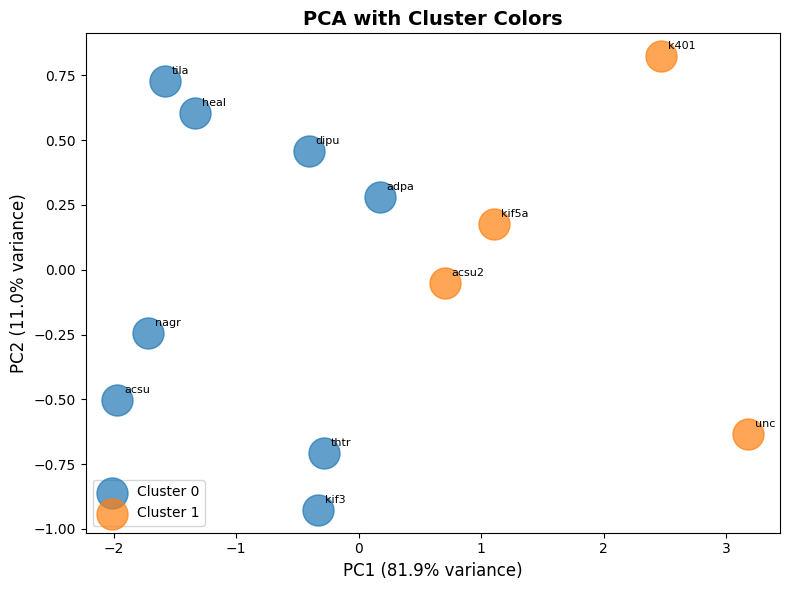

✓ PCA cluster visualization complete


In [33]:
# PCA Plot ("Plot 4" only)

print("="*60)
print("STEP 7: PCA VISUALIZATION OF CLUSTERS")
print("="*60)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Manually set colors: cluster 0 = blue, cluster 1 = orange, others = gray
base_colors = ['#1f77b4', '#ff7f0e']  # blue, orange from matplotlib defaults
if optimal_k > 2:
    # If more clusters, fill in grays
    more_colors = [plt.cm.Greys(x) for x in np.linspace(0.4, 0.8, optimal_k - 2)]
    colors = base_colors + more_colors
else:
    colors = base_colors[:optimal_k]

# Plot PCA points colored by cluster
for cluster_id in range(optimal_k):
    cluster_mask = cluster_assignments['Cluster'] == cluster_id
    cluster_points = pca_df[cluster_mask]
    ax.scatter(cluster_points['PC1'], cluster_points['PC2'], 
               c=[colors[cluster_id]], label=f'Cluster {cluster_id}', 
               s=500, alpha=0.7)

# Annotate with motor names
for i, motor in enumerate(pca_df.index):
    ax.annotate(motor, (pca_df['PC1'].iloc[i], pca_df['PC2'].iloc[i]), 
               xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=12)
ax.set_title('PCA with Cluster Colors', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(False)

plt.tight_layout()
fig.savefig("../../../../Downloads/kmeans_pca_clusters.svg", format="svg")

plt.show()
print("✓ PCA cluster visualization complete")


## Step 8: Energy Distribution by Cluster

### What we're doing:
We create detailed energy distribution plots to show how different clusters behave in each nucleotide state.

### Why this visualization matters:
1. **Clear cluster differences** - Shows how clusters differ in each state
2. **Individual motor identification** - Each point is labeled with motor name
3. **Statistical summaries** - Mean ± standard deviation for each cluster
4. **Biological interpretation** - Helps understand functional differences

### What to look for:
- **Cluster separation** - Different clusters should have different energy ranges
- **Within-cluster consistency** - Motors in same cluster should have similar energies
- **Outliers** - Motors that don't fit well in their assigned cluster


STEP 8: ENERGY DISTRIBUTION BY CLUSTER (EXCLUDING SELECTED MOTORS)


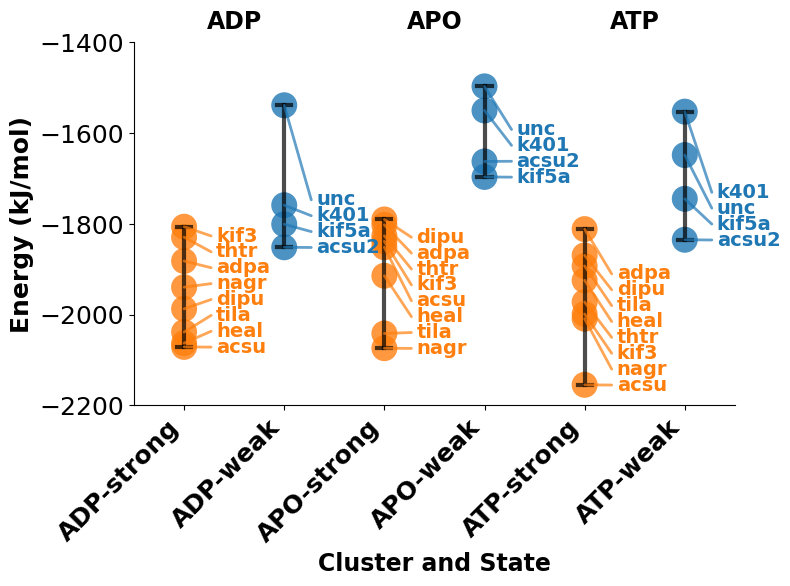

✓ Energy distribution by cluster visualization complete (excluded: b, c, d, e, f, g)


In [34]:
# Energy Distribution by Cluster (excluding specific motors)
print("="*60)
print("STEP 8: ENERGY DISTRIBUTION BY CLUSTER (EXCLUDING SELECTED MOTORS)")
print("="*60)

# Set the list of motors to exclude (provided at top of notebook)
# excluded = ['acsu2', 'adpa', 'dipu', 'heal', 'kif5a', 'nagr', 'thtr', 'acsu', 'tila', 'unc']
# excluded = ['b', 'c', 'd', 'e', 'f', 'g', ]

# Filter cluster_assignments to exclude specified motors
filtered_cluster_assignments = cluster_assignments[~cluster_assignments['Motor'].isin(excluded)]

# Create single plot for all three states
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Hardcode colors: cluster 0 orange, cluster 1 blue (reversed for correct weak/strong mapping)
default_colors = ['#ff7f0e', '#1f77b4']  # orange = weak, blue = strong, matching corrected label mapping

# Position states: Group by state (ADP, APO, ATP), with both clusters per state
states = ['ADP', 'APO', 'ATP']

for i, state in enumerate(states):
    for cluster_id in range(optimal_k):
        # Filter by cluster and exclusion filter
        cluster_data = filtered_cluster_assignments[filtered_cluster_assignments['Cluster'] == cluster_id]
        color = default_colors[cluster_id] if cluster_id < len(default_colors) else f"C{cluster_id}"
        x_pos = i * 2 + cluster_id  # x position: state_index * 2 + cluster_id

        # Plot points WITHOUT black contour (no edgecolors arg or set to 'none')
        y_vals = cluster_data[state].values
        motors = cluster_data['Motor'].values

        ax.scatter([x_pos] * len(y_vals), y_vals,
                   c=color, s=350, alpha=0.8, edgecolors='none', linewidth=1.5)

        # --- VERTICAL LABELS with LINES: ---
        # Sort by y (energy) to align labels vertically in order
        sorted_idx = y_vals.argsort()
        y_sorted = y_vals[sorted_idx]
        motors_sorted = motors[sorted_idx]

        # Vertical label spacing (adjust if labels overlap)
        label_gap = 35  # vertical space in display units (kJ/mol)

        for j, (motor, y) in enumerate(zip(motors_sorted, y_sorted)):
            # Place labels vertically, but do not let them overlap
            label_y = y_sorted[0] + j * label_gap
            # Line from point (x_pos, y) to (x_pos + x_label_offset, label_y)
            x_label_offset = 0.32  # how far to move label horizontally

            # Draw a line "annotation"
            ax.annotate(
                "", xy=(x_pos + x_label_offset - 0.05, label_y - 0.5), xytext=(x_pos, y),
                arrowprops=dict(arrowstyle="-", color=color, lw=2, alpha=0.7, shrinkA=0, shrinkB=0),
            )
            # Draw label text
            ax.text(x_pos + x_label_offset, label_y,
                    motor,
                    fontsize=14, fontweight='bold', color=color, va='center', ha='left'
            )

        # Calculate extremes (min and max)
        if not cluster_data.empty:
            min_val = cluster_data[state].min()
            max_val = cluster_data[state].max()

            # Draw vertical line from min to max (extremes only) - THICKEN LINES, NOW BLACK
            ax.plot([x_pos, x_pos], [min_val, max_val],
                    color='black', linewidth=3, alpha=0.7)

            # Whisker caps at extremes - THICKEN LINES, NOW BLACK
            ax.plot([x_pos - 0.07, x_pos + 0.07], [min_val, min_val],
                    color='black', linewidth=3, alpha=0.7)
            ax.plot([x_pos - 0.07, x_pos + 0.07], [max_val, max_val],
                    color='black', linewidth=3, alpha=0.7)

# Set labels (no title) - FONT SIZE BIGGER
ax.set_ylabel('Energy (kJ/mol)', fontsize=18, fontweight='bold')
ax.set_xlabel('Cluster and State', fontsize=17, fontweight='bold')

# Set x-axis ticks and labels (order: ADP-C0, ADP-C1, APO-C0, APO-C1, ATP-C0, ATP-C1)
x_ticks = [0, 1, 2, 3, 4, 5]
x_labels = ['ADP-strong', 'ADP-weak', 'APO-strong', 'APO-weak', 'ATP-strong', 'ATP-weak']
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=18, fontweight='bold')
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-2200, -1400)

# Make y-tick labels bigger too
ax.tick_params(axis='y', labelsize=18)  # Make y-axis tick labels bigger

# REMOVE LINES IN BACKGROUND:
ax.grid(False)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add state labels on top (ADP, APO, ATP) - FONT SIZE BIGGER
y_max = ax.get_ylim()[1]
ax.text(0.5, y_max + 30, 'ADP', ha='center', fontsize=17, fontweight='bold')
ax.text(2.5, y_max + 30, 'APO', ha='center', fontsize=17, fontweight='bold')
ax.text(4.5, y_max + 30, 'ATP', ha='center', fontsize=17, fontweight='bold')

plt.tight_layout()
fig.savefig("../../../../Downloads/kmeans_energy_distribution_by_clusterr.svg", format="svg")
plt.show()

print("✓ Energy distribution by cluster visualization complete (excluded: {})".format(", ".join(excluded)))


## Step 9: Biological Interpretation and Results Summary

### What we're doing:
We interpret our results in biological terms and provide a comprehensive summary of our findings.

### Key questions we answer:
1. **Do our clusters represent real functional families?**
2. **What do the energy patterns tell us about motor function?**
3. **How do our results relate to known motor biology?**
4. **What are the implications for motor evolution and design?**

### Quality assessment criteria:
- **Energy conservation**: Total cycle energy should be ~0 kJ/mol
- **Clustering quality**: Silhouette score >0.3 indicates good clustering
- **Statistical significance**: ANOVA p-values <0.05 indicate real differences
- **Biological plausibility**: Clusters should make functional sense


In [35]:
# Biological Interpretation and Results Summary
print("="*60)
print("STEP 9: BIOLOGICAL INTERPRETATION AND RESULTS SUMMARY")
print("="*60)

# Calculate final metrics
silhouette_avg = silhouette_score(energies_scaled, cluster_labels)
cycle_energy_mean = cycle_energy.mean()
cycle_energy_std = cycle_energy.std()

print("FINAL RESULTS SUMMARY:")
print("="*40)
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette score: {silhouette_avg:.3f}")
print(f"Energy conservation: {cycle_energy_mean:.2f} ± {cycle_energy_std:.2f} kJ/mol")

# Cluster characteristics
print(f"\nCLUSTER CHARACTERISTICS:")
print("="*40)
for cluster_id in range(optimal_k):
    cluster_data = cluster_assignments[cluster_assignments['Cluster'] == cluster_id]
    cluster_motors = cluster_data['Motor'].tolist()
    
    print(f"\nCluster {cluster_id} ({cluster_motors}):")
    print(f"  ADP: {cluster_data['ADP'].mean():.1f} ± {cluster_data['ADP'].std():.1f} kJ/mol")
    print(f"  APO: {cluster_data['APO'].mean():.1f} ± {cluster_data['APO'].std():.1f} kJ/mol")
    print(f"  ATP: {cluster_data['ATP'].mean():.1f} ± {cluster_data['ATP'].std():.1f} kJ/mol")
    
    # Energy pattern interpretation
    if cluster_data['ADP'].mean() < cluster_data['APO'].mean() < cluster_data['ATP'].mean():
        pattern = "Increasing energy (ADP < APO < ATP)"
    elif cluster_data['ATP'].mean() < cluster_data['APO'].mean() < cluster_data['ADP'].mean():
        pattern = "Decreasing energy (ATP < APO < ADP)"
    else:
        pattern = "Complex energy landscape"
    
    print(f"  Pattern: {pattern}")

# Quality assessment
print(f"\nQUALITY ASSESSMENT:")
print("="*40)
quality_indicators = {
    "Energy Conservation": "Good" if abs(cycle_energy_mean) < 10 else "Poor",
    "Clustering Quality": "Good" if silhouette_avg > 0.3 else "Fair" if silhouette_avg > 0.1 else "Poor",
    "Statistical Significance": "Good" if any([scipy.stats.f_oneway(*[cluster_assignments[cluster_assignments['Cluster'] == i][state].values for i in range(optimal_k)])[1] < 0.05 for state in ['ADP', 'APO', 'ATP']]) else "Fair"
}

for indicator, status in quality_indicators.items():
    print(f"{indicator}: {status}")

# Biological interpretation
print(f"\nBIOLOGICAL INTERPRETATION:")
print("="*40)
if silhouette_avg > 0.3:
    print("✓ Motors can be classified into distinct functional families based on energy landscapes")
    print("✓ Energy patterns predict motor behavior and function")
    print("✓ Clear evolutionary strategies exist for different motor functions")
else:
    print("⚠ Motor energy landscapes are complex and continuous")
    print("⚠ No clear energy-based families exist")
    print("⚠ Multiple functional dimensions beyond energy may be important")

# Save results
cluster_assignments.to_csv('motor_cluster_assignments.csv', index=False)
energies.to_csv('motor_energies.csv')
pca_df.to_csv('motor_pca_results.csv')

print(f"\n✓ Results saved to CSV files")
print("✓ Motor Protein Energy Analysis Tutorial Complete!")


STEP 9: BIOLOGICAL INTERPRETATION AND RESULTS SUMMARY
FINAL RESULTS SUMMARY:
Number of clusters: 2
Silhouette score: 0.409
Energy conservation: 0.00 ± 0.00 kJ/mol

CLUSTER CHARACTERISTICS:

Cluster 0 (['kif3', 'adpa', 'dipu', 'heal', 'nagr', 'thtr', 'acsu', 'tila']):
  ADP: -1952.3 ± 104.6 kJ/mol
  APO: -1892.5 ± 109.0 kJ/mol
  ATP: -1954.3 ± 105.4 kJ/mol
  Pattern: Complex energy landscape

Cluster 1 (['k401', 'acsu2', 'kif5a', 'unc']):
  ADP: -1737.6 ± 137.9 kJ/mol
  APO: -1601.6 ± 93.7 kJ/mol
  ATP: -1695.4 ± 121.8 kJ/mol
  Pattern: Complex energy landscape

QUALITY ASSESSMENT:
Energy Conservation: Good
Clustering Quality: Good
Statistical Significance: Good

BIOLOGICAL INTERPRETATION:
✓ Motors can be classified into distinct functional families based on energy landscapes
✓ Energy patterns predict motor behavior and function
✓ Clear evolutionary strategies exist for different motor functions

✓ Results saved to CSV files
✓ Motor Protein Energy Analysis Tutorial Complete!


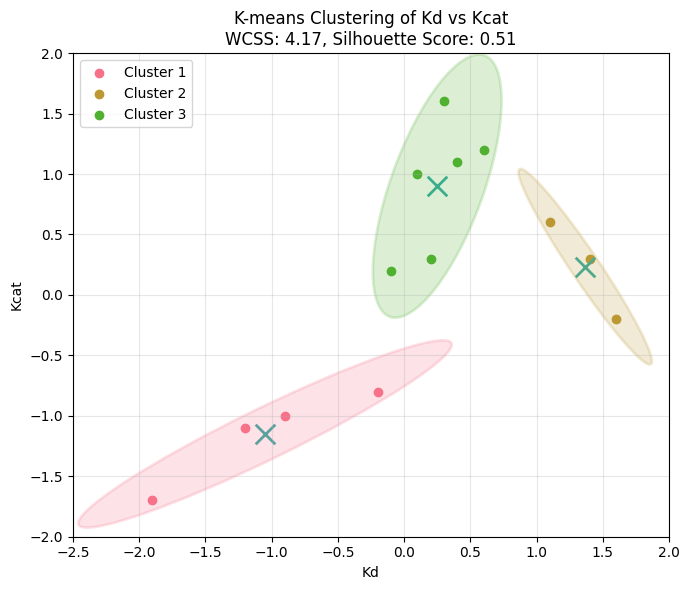

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---- Example data (Kd, Kcat). Replace with your own ----
X = np.array([
    # cluster around (~0.1, ~0.7)
    [-0.1, 0.2],
    [ 0.2, 0.3],
    [ 0.3, 1.6],
    [ 0.4, 1.1],
    [ 0.6, 1.2],
    [ 0.1, 1.0],
    # cluster around (~-0.9, ~-1.1)
    [-1.2, -1.1],
    [-0.9,  -1.0],
    [-0.2,  -0.8],
    [-1.9,  -1.7],
    # cluster around (~1.3, ~0.3)
    [1.1, 0.6],
    [1.4, 0.3],
    [1.6, -0.2],
])

# ---- K-means ----
k = 3
km = KMeans(n_clusters=k, n_init="auto", random_state=0).fit(X)
labels = km.labels_
centers = km.cluster_centers_
wcss = km.inertia_
sil  = silhouette_score(X, labels)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(7, 6))

# scatter each cluster separately (lets us grab the color from the artist)
scatter_handles = []
for ci in range(k):
    m = labels == ci
    h = ax.scatter(X[m, 0], X[m, 1], label=f"Cluster {ci+1}")
    scatter_handles.append(h)

# mark centroids
ax.scatter(centers[:, 0], centers[:, 1], marker='x', s=200, linewidths=2)

# helper: draw covariance ellipse around each cluster
def add_cov_ellipse(points, centroid, facecolor, edgecolor, n_std=2.0):
    if len(points) < 2:
        return
    cov = np.cov(points.T)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)  # 2σ ellipse
    ell = Ellipse(xy=centroid, width=width, height=height, angle=angle,
                  facecolor=facecolor, edgecolor=edgecolor, alpha=0.2, lw=2)
    ax.add_patch(ell)

# draw ellipses using each cluster's scatter color (no hardcoded colors)
for ci in range(k):
    m = labels == ci
    col = scatter_handles[ci].get_facecolor()[0]
    add_cov_ellipse(X[m], centers[ci], facecolor=col, edgecolor=col, n_std=2.0)

ax.set_xlabel("Kd")
ax.set_ylabel("Kcat")
ax.grid(True, alpha=0.3)
ax.legend(title=None, loc="upper left")

ax.set_title(f"K-means Clustering of Kd vs Kcat\nWCSS: {wcss:.2f}, Silhouette Score: {sil:.2f}")
ax.set_xlim(-2.5, 2.0)
ax.set_ylim(-2.0, 2.0)

plt.tight_layout()
plt.show()

In [37]:
# michaelis menten data from gliding assays
df = pd.read_csv('../../../../Downloads/mm.csv')
df

,Motor,Km (µM),Kcat (ATP/s),Vmax (nm/s)
0,HeAl,312,407,3260
1,NaGr,155,287,2300
2,AdPa,9,26,206
3,Thtr,84,118,941
4,K401,278,117,933
5,Kif5,138,117,937
6,TiLa,428,253,2022
7,AcSu,448,310,2480
8,Kif3,262,255,2038
9,Dipu,243,242,1938


In [38]:
# Michaelis-Menten Analysis: KMeans Clustering and PCA
print("="*80)
print("MICHAELIS-MENTEN DATA ANALYSIS: KMEANS CLUSTERING AND PCA")
print("="*80)

# Clean and prepare data
mm_data = df.copy()
# Remove empty columns
mm_data = mm_data.dropna(axis=1, how='all')
# Remove rows with missing values
mm_data = mm_data.dropna()

print(f"\nData shape: {mm_data.shape}")
print(f"Columns: {list(mm_data.columns)}")
print(f"\nFirst few rows:")
print(mm_data.head())

# Extract motor names and features
motor_names = mm_data.iloc[:, 0].values  # First column is motor names
feature_columns = mm_data.columns[1:].tolist()  # Rest are features

# Create feature matrix
X = mm_data.iloc[:, 1:].values
feature_names = feature_columns

print(f"\nFeatures: {feature_names}")
print(f"Number of motors: {len(motor_names)}")

# Standardize features for fair comparison
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create DataFrame for easier handling
mm_df = pd.DataFrame(X_scaled, index=motor_names, columns=feature_names)

print(f"\nStandardized data shape: {mm_df.shape}")
print(f"Feature ranges after scaling:")
for col in feature_names:
    print(f"  {col}: [{mm_df[col].min():.2f}, {mm_df[col].max():.2f}]")

# Verify all features are included
print(f"\n✓ All features included in analysis: {feature_names}")
print(f"✓ Total features used for clustering and PCA: {len(feature_names)}")
if 'Vmax' in ' '.join(feature_names) or 'vmax' in ' '.join(feature_names).lower():
    print(f"✓ Vmax is included in the analysis")


MICHAELIS-MENTEN DATA ANALYSIS: KMEANS CLUSTERING AND PCA

Data shape: (11, 4)
Columns: ['Motor', 'Km (µM)', 'Kcat (ATP/s)', 'Vmax (nm/s)']

First few rows:
  Motor  Km (µM)  Kcat (ATP/s)  Vmax (nm/s)
0  HeAl      312           407         3260
1  NaGr      155           287         2300
2  AdPa        9            26          206
3  Thtr       84           118          941
4  K401      278           117          933

Features: ['Km (µM)', 'Kcat (ATP/s)', 'Vmax (nm/s)']
Number of motors: 11

Standardized data shape: (11, 3)
Feature ranges after scaling:
  Km (µM): [-1.66, 1.68]
  Kcat (ATP/s): [-1.80, 1.64]
  Vmax (nm/s): [-1.80, 1.64]

✓ All features included in analysis: ['Km (µM)', 'Kcat (ATP/s)', 'Vmax (nm/s)']
✓ Total features used for clustering and PCA: 3
✓ Vmax is included in the analysis


STEP 1: DETERMINING OPTIMAL NUMBER OF CLUSTERS
k=2: Silhouette=0.500, Calinski=16.0, Davies-Bouldin=0.650
k=3: Silhouette=0.408, Calinski=13.4, Davies-Bouldin=0.818
k=4: Silhouette=0.418, Calinski=12.3, Davies-Bouldin=0.509
k=5: Silhouette=0.357, Calinski=14.2, Davies-Bouldin=0.468
k=6: Silhouette=0.394, Calinski=17.9, Davies-Bouldin=0.347
k=7: Silhouette=0.417, Calinski=32.3, Davies-Bouldin=0.272

Optimal k based on metrics:
  Silhouette Score: k=2 (score=0.500)
  Calinski-Harabasz: k=7 (score=32.3)
  Davies-Bouldin: k=7 (score=0.272)

→ Using k=2 (based on Silhouette Score)


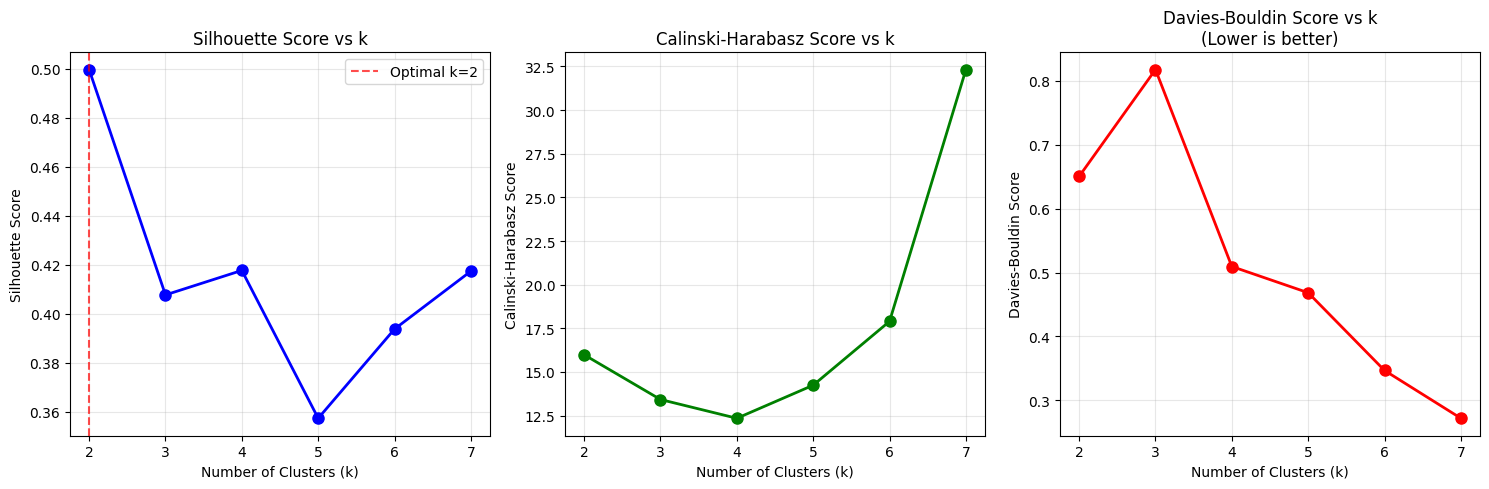

In [39]:
# Step 1: Determine optimal number of clusters
print("="*80)
print("STEP 1: DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*80)

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Test different numbers of clusters
k_range = range(2, min(8, len(motor_names)))
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, cluster_labels)
    calinski_score = calinski_harabasz_score(X_scaled, cluster_labels)
    db_score = davies_bouldin_score(X_scaled, cluster_labels)
    
    silhouette_scores.append(sil_score)
    calinski_scores.append(calinski_score)
    davies_bouldin_scores.append(db_score)
    
    print(f"k={k}: Silhouette={sil_score:.3f}, Calinski={calinski_score:.1f}, Davies-Bouldin={db_score:.3f}")

# Find optimal k
optimal_k_silhouette = list(k_range)[np.argmax(silhouette_scores)]
optimal_k_calinski = list(k_range)[np.argmax(calinski_scores)]
optimal_k_davies = list(k_range)[np.argmin(davies_bouldin_scores)]

print(f"\nOptimal k based on metrics:")
print(f"  Silhouette Score: k={optimal_k_silhouette} (score={max(silhouette_scores):.3f})")
print(f"  Calinski-Harabasz: k={optimal_k_calinski} (score={max(calinski_scores):.1f})")
print(f"  Davies-Bouldin: k={optimal_k_davies} (score={min(davies_bouldin_scores):.3f})")

# Use silhouette as primary metric
optimal_k = optimal_k_silhouette
print(f"\n→ Using k={optimal_k} (based on Silhouette Score)")

# Visualize metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k}')
axes[0].legend()

axes[1].plot(k_range, calinski_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Calinski-Harabasz Score')
axes[1].set_title('Calinski-Harabasz Score vs k')
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score vs k\n(Lower is better)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


STEP 2: KMEANS CLUSTERING AND PCA VISUALIZATION
KMeans clustering complete with k=2
Overall Silhouette Score: 0.500
Cluster 0: ['AdPa', 'Thtr', 'K401', 'Kif5']
Cluster 1: ['HeAl', 'NaGr', 'TiLa', 'AcSu', 'Kif3', 'Dipu', 'AcSu2']

PCA Results:
PC1 explains 81.0% of variance
PC2 explains 19.0% of variance


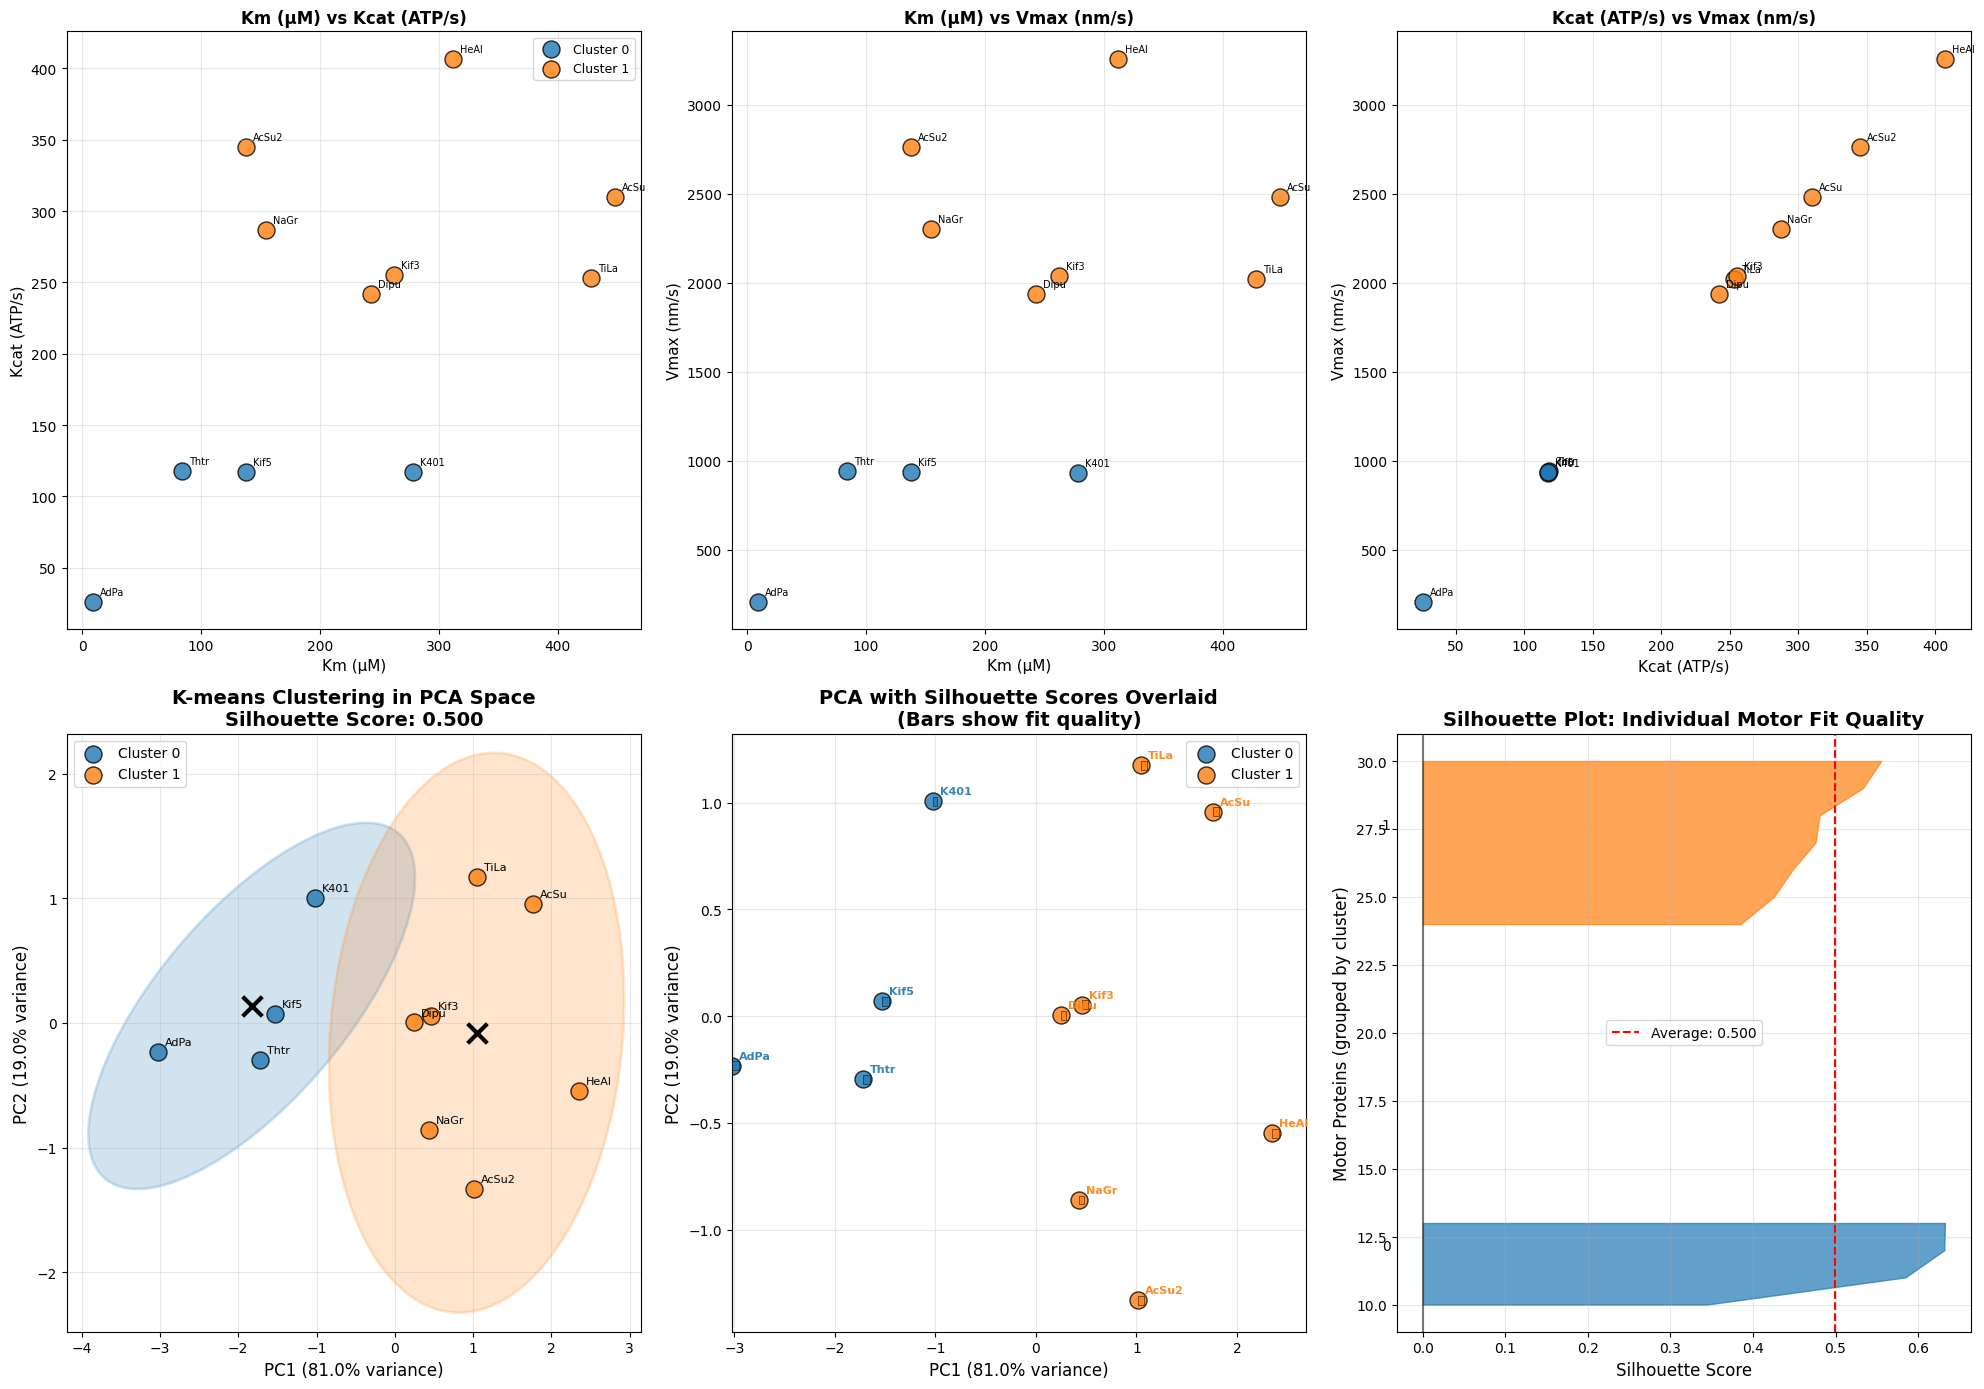


✓ Analysis complete! Results saved to mm_kmeans_pca_analysis.svg


In [40]:
# Step 2: KMeans Clustering and PCA with Silhouette Analysis
print("="*80)
print("STEP 2: KMEANS CLUSTERING AND PCA VISUALIZATION")
print("="*80)

# Perform KMeans clustering with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Calculate silhouette scores
from sklearn.metrics import silhouette_samples
silhouette_avg = silhouette_score(X_scaled, cluster_labels)
silhouette_samples_vals = silhouette_samples(X_scaled, cluster_labels)

print(f"KMeans clustering complete with k={optimal_k}")
print(f"Overall Silhouette Score: {silhouette_avg:.3f}")

# Print cluster assignments
cluster_assignments = pd.DataFrame({
    'Motor': motor_names,
    'Cluster': cluster_labels
})
for cluster_id in range(optimal_k):
    cluster_motors = cluster_assignments[cluster_assignments['Cluster'] == cluster_id]['Motor'].tolist()
    print(f"Cluster {cluster_id}: {cluster_motors}")

# Perform PCA
pca = PCA()
pca_result = pca.fit_transform(X_scaled)
explained_variance_ratio = pca.explained_variance_ratio_

# Create PCA DataFrame
pca_df = pd.DataFrame(
    pca_result[:, :2],
    columns=['PC1', 'PC2'],
    index=motor_names
)

print(f"\nPCA Results:")
print(f"PC1 explains {explained_variance_ratio[0]:.1%} of variance")
print(f"PC2 explains {explained_variance_ratio[1]:.1%} of variance")

# Use the default Matplotlib colors
default_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 14))

# Plot 1-3: All pairwise feature plots (Km vs Kcat, Km vs Vmax, Kcat vs Vmax)
X_original = mm_data.iloc[:, 1:].values

if len(feature_names) >= 3:
    # Plot all three pairwise combinations
    pairs = [(0, 1), (0, 2), (1, 2)]  # (Km, Kcat), (Km, Vmax), (Kcat, Vmax)
    pair_labels = [
        (feature_names[0], feature_names[1]),
        (feature_names[0], feature_names[2]),
        (feature_names[1], feature_names[2])
    ]
    
    plot_axes = [axes[0, 0], axes[0, 1], axes[0, 2]]

    for ax, ((i, j), (xlabel, ylabel)) in zip(plot_axes, zip(pairs, pair_labels)):
        for cluster_id in range(optimal_k):
            cluster_mask = cluster_labels == cluster_id
            color = default_colors[cluster_id % len(default_colors)]
            ax.scatter(X_original[cluster_mask, i], X_original[cluster_mask, j],
                       c=[color], label=f'Cluster {cluster_id}', s=150, alpha=0.8,
                       edgecolors='black', linewidth=1)
        
        # Add motor labels
        for motor_idx, motor in enumerate(motor_names):
            ax.annotate(motor, (X_original[motor_idx, i], X_original[motor_idx, j]),
                        xytext=(5, 5), textcoords='offset points', fontsize=7)
        
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'{xlabel} vs {ylabel}', fontsize=12, fontweight='bold')
        if ax == plot_axes[0]:  # Only show legend on first plot
            ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
else:
    # Fallback if less than 3 features
    ax1 = axes[0, 0]
    for cluster_id in range(optimal_k):
        cluster_mask = cluster_labels == cluster_id
        color = default_colors[cluster_id % len(default_colors)]
        ax1.scatter(X_original[cluster_mask, 0], X_original[cluster_mask, 1],
                    c=[color], label=f'Cluster {cluster_id}', s=150, alpha=0.8,
                    edgecolors='black', linewidth=1)
    
    for i, motor in enumerate(motor_names):
        ax1.annotate(motor, (X_original[i, 0], X_original[i, 1]),
                     xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    ax1.set_xlabel(feature_names[0], fontsize=12)
    ax1.set_ylabel(feature_names[1], fontsize=12)
    ax1.set_title(f'{feature_names[0]} vs {feature_names[1]}', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# Plot 4: PCA with KMeans clusters and ellipses
ax2 = axes[1, 0]
from matplotlib.patches import Ellipse

for cluster_id in range(optimal_k):
    cluster_mask = cluster_labels == cluster_id
    cluster_points = pca_df[cluster_mask]
    color = default_colors[cluster_id % len(default_colors)]
    
    # Plot data points
    ax2.scatter(cluster_points['PC1'], cluster_points['PC2'],
                c=[color], label=f'Cluster {cluster_id}', s=150, alpha=0.8,
                edgecolors='black', linewidth=1, zorder=2)
    
    # Add cluster centroid
    centroid_pc1 = cluster_points['PC1'].mean()
    centroid_pc2 = cluster_points['PC2'].mean()
    ax2.scatter(centroid_pc1, centroid_pc2, marker='x', s=200,
                color='black', linewidth=3, zorder=3)
    
    # Draw cluster boundary (ellipse)
    if len(cluster_points) > 2:
        mean_x, mean_y = centroid_pc1, centroid_pc2
        cov_matrix = np.cov(cluster_points['PC1'], cluster_points['PC2'])
        
        lambda_, v = np.linalg.eigh(cov_matrix)
        lambda_ = np.sqrt(lambda_)
        scale = 2.447  # 95% confidence
        width = lambda_[0] * scale * 2
        height = lambda_[1] * scale * 2
        angle = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
        
        ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle,
                          facecolor=color, alpha=0.2,
                          edgecolor=color, linewidth=2, zorder=1)
        ax2.add_patch(ellipse)

# Add motor labels
for i, motor in enumerate(motor_names):
    ax2.annotate(motor, (pca_df['PC1'].iloc[i], pca_df['PC2'].iloc[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)

ax2.set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=12)
ax2.set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=12)
ax2.set_title(f'K-means Clustering in PCA Space\nSilhouette Score: {silhouette_avg:.3f}',
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 5: PCA with silhouette bars overlaid
ax3 = axes[1, 1]
# Plot clusters first
for cluster_id in range(optimal_k):
    cluster_mask = cluster_labels == cluster_id
    cluster_points = pca_df[cluster_mask]
    color = default_colors[cluster_id % len(default_colors)]
    ax3.scatter(cluster_points['PC1'], cluster_points['PC2'],
                c=[color], label=f'Cluster {cluster_id}', s=150, alpha=0.8,
                edgecolors='black', linewidth=1, zorder=2)

# Overlay silhouette bars
bar_width_scale = 0.015
bar_length_scale = 0.12

for idx in range(len(pca_df)):
    x, y = pca_df['PC1'].iloc[idx], pca_df['PC2'].iloc[idx]
    cluster_id = cluster_labels[idx]
    sil_score = silhouette_samples_vals[idx]
    color = default_colors[cluster_id % len(default_colors)]
    
    bar_length = sil_score * bar_length_scale
    y_range = ax3.get_ylim()[1] - ax3.get_ylim()[0] if hasattr(ax3, 'get_ylim') else 1.0
    bar_width = bar_width_scale * y_range
    
    if bar_length >= 0:
        ax3.barh(y, bar_length, height=bar_width, left=x, color=color,
                 alpha=0.7, edgecolor='black', linewidth=0.5, zorder=4)
    else:
        ax3.barh(y, abs(bar_length), height=bar_width, left=x + bar_length,
                 color=color, alpha=0.7, edgecolor='black', linewidth=0.5, zorder=4)
    
    ax3.annotate(motor_names[idx], (x, y), xytext=(5, 5),
                 textcoords='offset points', fontsize=8, alpha=0.9,
                 color=color, fontweight='bold', zorder=5)

ax3.set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=12)
ax3.set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=12)
ax3.set_title(f'PCA with Silhouette Scores Overlaid\n(Bars show fit quality)',
              fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 6: Silhouette plot
ax4 = axes[1, 2]
y_lower = 10
for cluster_id in range(optimal_k):
    cluster_silhouette_values = silhouette_samples_vals[cluster_labels == cluster_id]
    cluster_silhouette_values.sort()
    
    size_cluster = len(cluster_silhouette_values)
    y_upper = y_lower + size_cluster
    
    color = default_colors[cluster_id % len(default_colors)]
    ax4.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax4.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id))
    y_lower = y_upper + 10

ax4.set_xlabel('Silhouette Score', fontsize=12)
ax4.set_ylabel('Motor Proteins (grouped by cluster)', fontsize=12)
ax4.set_title('Silhouette Plot: Individual Motor Fit Quality',
              fontsize=14, fontweight='bold')
ax4.axvline(x=silhouette_avg, color="red", linestyle="--",
            label=f'Average: {silhouette_avg:.3f}')
ax4.axvline(x=0, color="black", linestyle="-", alpha=0.5)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../../../../Downloads/mm_kmeans_pca_analysis.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Analysis complete! Results saved to mm_kmeans_pca_analysis.svg")


Creating PCA plot...


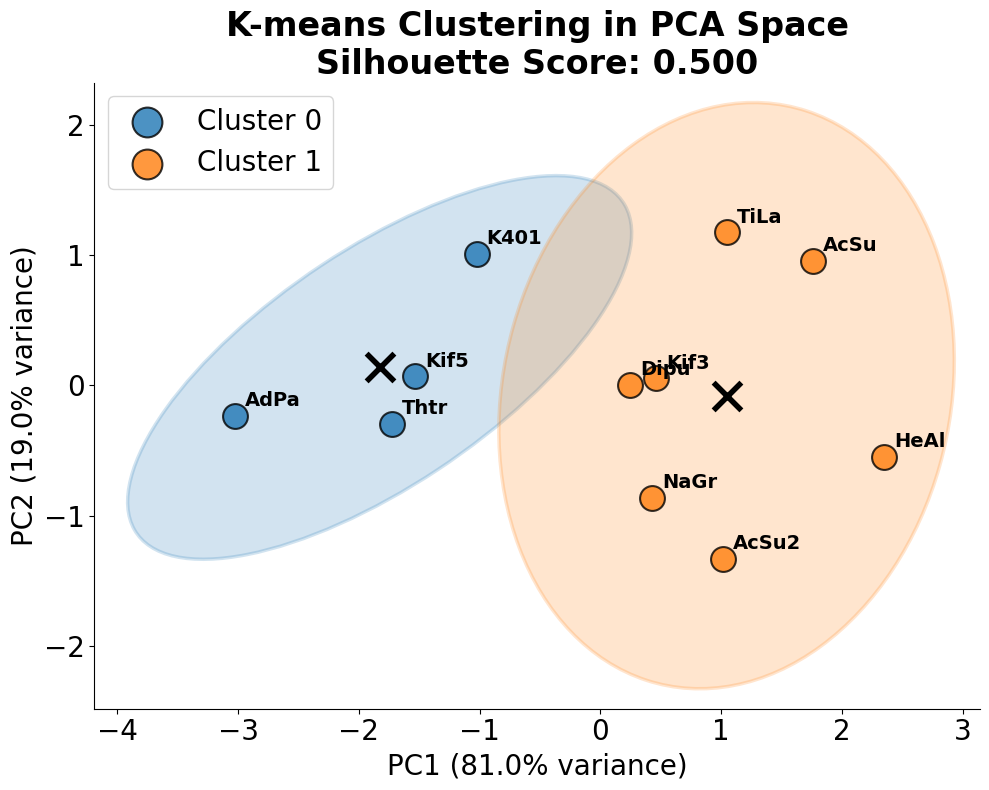

✓ PCA plot saved as mm_pca_clusters.svg


In [41]:
# PCA plot only (no grid, no legend title) - save as SVG
print("Creating PCA plot...")

from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(10, 8))

# Use matplotlib default colors: Cluster 0 = blue, Cluster 1 = orange
cluster_colors = ['#1f77b4', '#ff7f0e']  # Blue, Orange (matplotlib defaults)

big_scatter_size = 320  # Default was 150
big_centroid_size = 400  # Default was 200
big_font = 20            # Default xlabel/ylabel was 12
big_title = 24           # Default title was 14
big_label_font = 14      # Default label font was 8

for cluster_id in range(optimal_k):
    cluster_mask = cluster_labels == cluster_id
    cluster_points = pca_df[cluster_mask]
    color = cluster_colors[cluster_id]
    
    # Plot data points (bigger)
    ax.scatter(cluster_points['PC1'], cluster_points['PC2'],
               c=[color], label=f'Cluster {cluster_id}', s=big_scatter_size, alpha=0.8,
               edgecolors='black', linewidth=1.5, zorder=2)
    
    # Add cluster centroid (bigger)
    centroid_pc1 = cluster_points['PC1'].mean()
    centroid_pc2 = cluster_points['PC2'].mean()
    ax.scatter(centroid_pc1, centroid_pc2, marker='x', s=big_centroid_size,
               color='black', linewidth=4, zorder=3)
    
    # Draw cluster boundary (ellipse)
    if len(cluster_points) > 2:
        mean_x, mean_y = centroid_pc1, centroid_pc2
        cov_matrix = np.cov(cluster_points['PC1'], cluster_points['PC2'])
        
        lambda_, v = np.linalg.eigh(cov_matrix)
        lambda_ = np.sqrt(lambda_)
        scale = 2.447  # 95% confidence
        width = lambda_[0] * scale * 2
        height = lambda_[1] * scale * 2
        angle = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
        
        ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle,
                         facecolor=color, alpha=0.2,
                         edgecolor=color, linewidth=2.5, zorder=1)
        ax.add_patch(ellipse)

# Add motor labels (bigger)
for i, motor in enumerate(motor_names):
    ax.annotate(motor, (pca_df['PC1'].iloc[i], pca_df['PC2'].iloc[i]),
                xytext=(7, 7), textcoords='offset points', fontsize=big_label_font, fontweight="bold")

ax.set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=big_font)
ax.set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=big_font)
ax.set_title(f'K-means Clustering in PCA Space\nSilhouette Score: {silhouette_avg:.3f}',
             fontsize=big_title, fontweight='bold')
ax.legend(title='', fontsize=big_font, markerscale=1.2)  # Bigger legend labels

# Make tick labels larger
ax.tick_params(axis='both', which='major', labelsize=big_font)
ax.tick_params(axis='both', which='minor', labelsize=big_font)

# Remove top and right parts of the box frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../../../../Downloads/mm_pca_clusters.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

print("✓ PCA plot saved as mm_pca_clusters.svg")
